# Backtesting with Chinese futures: the complete pysystemtrade tutorial

This is a practical companion to `docs/backtesting.md`. It follows the
manual from the quick "How do I?" recipes through data, configuration,
systems, stages, caching, accounting, optimisation, and the reference
material. Every market example is a Tushare-sourced Chinese future and every
runnable price example uses `dbFuturesSimData`; the stale price CSVs shipped
with the upstream project are never loaded.

The notebook is intentionally long. It is written to be read in order once,
then searched later. Four markets keep the examples quick and legible:

| Instrument | Market | Asset class |
|---|---|---|
| `SHFE_RB` | Shanghai rebar | Metals |
| `DCE_M` | Dalian soybean meal | Agriculture |
| `CFFEX_IF` | CSI 300 index future | Equity |
| `CFFEX_T` | 10-year Chinese government bond future | Bonds |

You need the Chinese MongoDB/Parquet stores described in
`docs/tushare_chinese_futures.md`. No Tushare token is needed: this notebook
only reads the already-seeded stores. Some sections deliberately create
temporary YAML, CSV, and pickle files; they live in an operating-system temp
directory and disappear immediately afterwards.

## A small warning about the manual

`docs/backtesting.md` has grown over many versions of pysystemtrade. Where a
name or default in the prose differs from the current code, this notebook uses
the current code and points out the difference. Copy the working cells here,
not an old traceback or typo from the manual.

In [1]:
%matplotlib inline
import inspect
import logging
import sys
import tempfile
import time
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

# Let pysystemtrade install its simulation logger, then keep the tutorial quiet.
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    from syslogging.logger import get_logger
    get_logger("chinese_backtesting_tutorial")
logging.getLogger().setLevel(logging.WARNING)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

TUTORIAL_DIR = Path.cwd()
if not (TUTORIAL_DIR / "config.yaml").exists():
    TUTORIAL_DIR = (
        Path.cwd() / "examples/chinese_futures/backtesting_tutorial"
    ).resolve()
assert (TUTORIAL_DIR / "config.yaml").exists(), "Run from the repo or notebook directory"
if str(TUTORIAL_DIR) not in sys.path:
    sys.path.insert(0, str(TUTORIAL_DIR))

CONFIG_PATH = TUTORIAL_DIR / "config.yaml"
INSTRUMENTS = ["SHFE_RB", "DCE_M", "CFFEX_IF", "CFFEX_T"]
FOCUS = "SHFE_RB"
PLOT_START = "2018-01-01"

In [2]:
from sysdata.sim.db_futures_sim_data import dbFuturesSimData

data = dbFuturesSimData()
available = set(data.get_instrument_list())
missing = sorted(set(INSTRUMENTS) - available)
assert not missing, f"Seed/rebuild the missing Chinese histories first: {missing}"

metadata = data.get_all_instrument_data_as_df().loc[INSTRUMENTS]
coverage = pd.DataFrame({
    "first": {code_: data.daily_prices(code_).index.min() for code_ in INSTRUMENTS},
    "last": {code_: data.daily_prices(code_).index.max() for code_ in INSTRUMENTS},
    "rows": {code_: len(data.daily_prices(code_)) for code_ in INSTRUMENTS},
})
display(metadata[["Description", "Pointsize", "Currency", "AssetClass"]].join(coverage))
print(f"Chinese simulation universe: {len(available)} stitched instruments")

,Description,Pointsize,Currency,AssetClass,first,last,rows
Instrument,,,,,,,
SHFE_RB,Shanghai steel rebar,10.0000,CNH,Metals,2009-10-16,2026-07-27,4377
DCE_M,Dalian soybean meal,10.0000,CNH,Ags,2001-01-16,2026-07-27,6660
CFFEX_IF,China CSI 300 equity index,300.0000,CNH,Equity,2010-05-19,2026-07-27,4224
CFFEX_T,China 10-year government bond,"10,000.0000",CNH,Bond,2015-08-21,2026-07-27,2852


Chinese simulation universe: 95 stitched instruments


# Part 1 — How do I?

The manual starts with recipes. We will do the same, but keep one system
alive so later sections can pull it apart.

## Experiment with one trading rule and one instrument

A rule is just a function from data to an uncapped signal. For a quick idea
you do not need a full `System`. This standalone EWMAC recalculates its own
volatility, which is convenient for exploration; the full system reuses the
raw-data stage instead.

index
2026-07-21   -2.1410
2026-07-22   -2.2418
2026-07-23   -2.2757
2026-07-24   -2.3195
2026-07-27   -2.3675
Freq: B, Name: price, dtype: float64

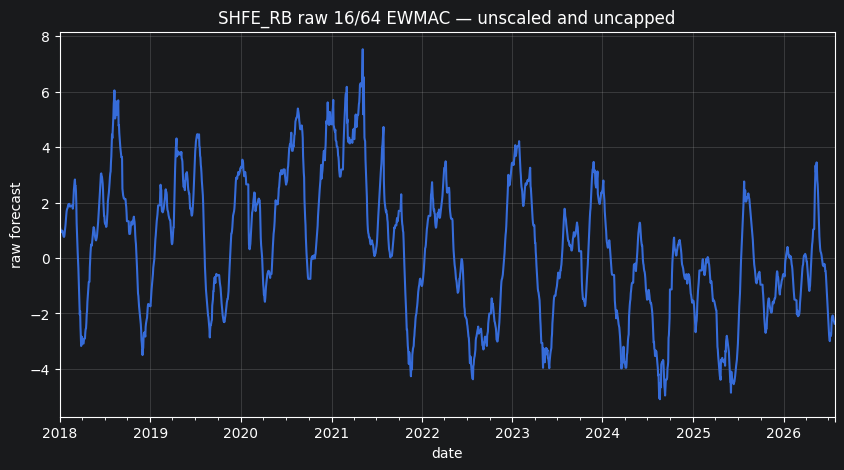

In [3]:
from systems.provided.rules.ewmac import ewmac_forecast_with_defaults

rebar_price = data.daily_prices(FOCUS)
standalone_ewmac = ewmac_forecast_with_defaults(
    rebar_price, Lfast=16, Lslow=64
)
ax = standalone_ewmac.loc[PLOT_START:].plot(
    title="SHFE_RB raw 16/64 EWMAC — unscaled and uncapped"
)
ax.set_ylabel("raw forecast")
ax.set_xlabel("date")
standalone_ewmac.dropna().tail()

<Axes: xlabel='index'>

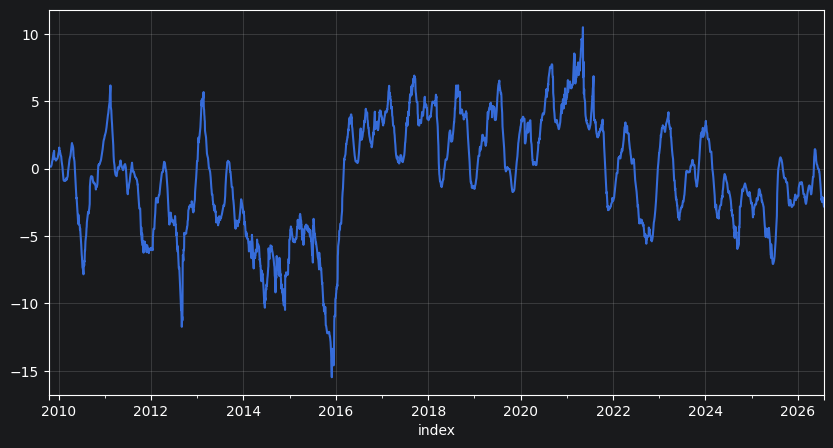

In [5]:
ewmac_forecast_with_defaults(
    rebar_price, Lfast=32, Lslow=128
).plot()

## Create a standard futures backtest

The tutorial folder contains a real, deliberately boring pre-baked system:
`system.py` chooses the seven standard stages, `config.yaml` supplies three
rules and four Chinese instruments, and `dbFuturesSimData` supplies the
Chinese stores. This is the same pattern as the chapter 15 system, without
its default CSV data.

In [4]:
from system import futures_system

fixed_system = futures_system()
print(fixed_system)
print("instruments:", fixed_system.get_instrument_list())
fixed_system.portfolio.get_notional_position(FOCUS).dropna().tail()

System base_system with .config, .data, and .stages: accounts, portfolio, positionSize, rawdata, combForecast, forecastScaleCap, rules
instruments: ['CFFEX_IF', 'CFFEX_T', 'DCE_M', 'SHFE_RB']


index
2026-07-21   -140.3797
2026-07-22   -143.0794
2026-07-23   -144.7315
2026-07-24   -147.5678
2026-07-27   -150.4502
Freq: B, dtype: float64

## Create a backtest which estimates parameters

Estimation is selected by configuration, not by a different class hierarchy.
For a clean comparison we keep the same three rules and four markets, remove
the fixed instrument weights, and estimate scalars, forecast weights, FDM,
instrument weights, and IDM. Weekly expanding-window handcrafting is the
current default and is fast for this small example.

In [5]:
from sysdata.config.configdata import Config

estimated_config = Config([
    str(CONFIG_PATH),
    {
        "instruments": INSTRUMENTS,
        "rule_variations": ["ewmac16_64", "ewmac32_128", "carry"],
        "use_forecast_scale_estimates": True,
        "use_forecast_weight_estimates": True,
        "use_forecast_div_mult_estimates": True,
        "use_instrument_weight_estimates": True,
        "use_instrument_div_mult_estimates": True,
        "forecast_weight_estimate": {"method": "handcraft", "date_method": "expanding"},
        "instrument_weight_estimate": {"method": "handcraft", "date_method": "expanding"},
    },
])
del estimated_config.instrument_weights

estimated_system = futures_system(
    data=dbFuturesSimData(), config=estimated_config
)
with redirect_stdout(StringIO()):
    estimated_forecast_weights = estimated_system.combForecast.get_forecast_weights(FOCUS)
    estimated_instrument_weights = estimated_system.portfolio.get_instrument_weights()

print("latest SHFE_RB forecast weights")
display(estimated_forecast_weights.dropna(how="all").tail(1))
print("latest portfolio instrument weights")
display(estimated_instrument_weights.dropna(how="all").tail(1))

latest SHFE_RB forecast weights


,ewmac16_64,carry,ewmac32_128
index,,,
2026-07-27,0.1823,0.6921,0.1256


latest portfolio instrument weights


,CFFEX_IF,CFFEX_T,DCE_M,SHFE_RB
index,,,,
2026-07-27,0.2430,0.2570,0.2570,0.2430


## See intermediate results

Every stage is inspectable. The sequence below is the backbone of the whole
notebook: adjusted prices → volatility and carry → raw forecasts → scaled and
capped forecasts → combined forecast → subsystem position → portfolio
position → buffered position and P&L.

In [6]:
intermediate = {
    "daily price": fixed_system.rawdata.get_daily_prices(FOCUS),
    "daily price-unit vol": fixed_system.rawdata.daily_returns_volatility(FOCUS),
    "raw carry": fixed_system.rawdata.raw_carry(FOCUS),
    "raw EWMAC": fixed_system.rules.get_raw_forecast(FOCUS, "ewmac16_64"),
    "capped EWMAC": fixed_system.forecastScaleCap.get_capped_forecast(
        FOCUS, "ewmac16_64"
    ),
    "combined forecast": fixed_system.combForecast.get_combined_forecast(FOCUS),
    "subsystem position": fixed_system.positionSize.get_subsystem_position(FOCUS),
    "portfolio position": fixed_system.portfolio.get_notional_position(FOCUS),
    "buffered position": fixed_system.accounts.get_buffered_position(FOCUS),
}
display(pd.concat(intermediate, axis=1).dropna(how="all").tail())
print("Try any_stage.methods() to discover the current public surface.")

,daily price,daily price-unit vol,raw carry,raw EWMAC,capped EWMAC,combined forecast,subsystem position,portfolio position,buffered position
index,,,,,,,,,
2026-07-21,"3,116.0000",24.6303,-0.2132,-1.4878,-5.5792,-9.2202,-374.3458,-140.3797,-143.0000
2026-07-22,"3,103.0000",24.4310,-0.2047,-1.5429,-5.7857,-9.3215,-381.5451,-143.0794,-143.0000
2026-07-23,"3,112.0000",24.2496,-0.2784,-1.5534,-5.8251,-9.3591,-385.9508,-144.7315,-143.0000
2026-07-24,"3,114.0000",23.9371,-0.3969,-1.5596,-5.8485,-9.4196,-393.5142,-147.5678,-143.0000
2026-07-27,"3,113.0000",23.6160,-0.3705,-1.5664,-5.8740,-9.4748,-401.2005,-150.4502,-143.0000


Try any_stage.methods() to discover the current public surface.


## See how profitable a backtest was

Account objects default to net daily P&L. `.percent` changes units, `.curve()`
accumulates returns, and `.stats()` describes the available statistics.
Never judge a system from one Sharpe ratio; this is API orientation, not an
investment conclusion.

,portfolio statistic
ann_mean,16.97
ann_std,14.51
sharpe,1.169
sortino,1.663
avg_drawdown,-5.268
skew,0.03796
t_stat,4.505
p_value,6.834e-06


Text(0.5, 0, 'date')

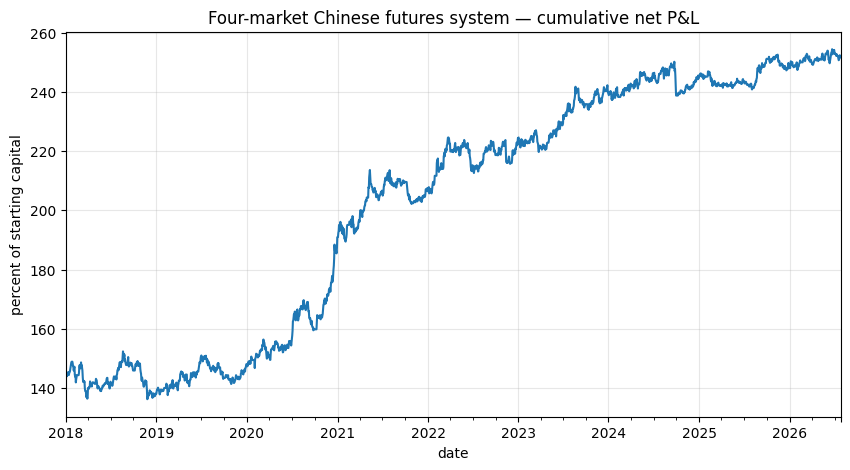

In [7]:
portfolio = fixed_system.accounts.portfolio()
stats = dict(portfolio.percent.stats()[0])
display(pd.Series({key: stats[key] for key in [
    "ann_mean", "ann_std", "sharpe", "sortino", "avg_drawdown",
    "skew", "t_stat", "p_value",
]}).to_frame("portfolio statistic"))

ax = portfolio.percent.curve().loc[PLOT_START:].plot(
    title="Four-market Chinese futures system — cumulative net P&L"
)
ax.set_ylabel("percent of starting capital")
ax.set_xlabel("date")

## Change backtest parameters

There are five routes in the manual:

1. edit or create a system YAML file;
2. change a `Config` object and build a new system;
3. mutate the config inside a live system and manage its cache carefully;
4. put global overrides in `private/private_config.yaml`;
5. edit project defaults.

The first two are normal. The third is demonstrated in the cache section.
The fourth is appropriate for genuinely global private settings, but this
notebook never prints or edits your private config. The fifth is deliberately
not performed: changing repository defaults would alter every system and many
tests.

In [8]:
changed_config = Config([
    str(CONFIG_PATH),
    {
        "percentage_vol_target": 12.0,
        "instrument_div_multiplier": 1.25,
    },
])
# Change one nested member. Replacing the whole dictionary after defaults are
# filled would silently discard every sibling setting.
changed_system = futures_system(
    data=dbFuturesSimData(), config=changed_config
)
changed_system.config.volatility_calculation["days"] = 20

pd.Series({
    "original vol target": fixed_system.config.percentage_vol_target,
    "changed vol target": changed_system.config.percentage_vol_target,
    "changed IDM": changed_system.config.instrument_div_multiplier,
    "changed fast-vol span": changed_system.config.volatility_calculation["days"],
})

original vol target     16.0000
changed vol target      12.0000
changed IDM              1.2500
changed fast-vol span   20.0000
dtype: float64

## Choose instruments and dates

For fixed weights, the keys of `instrument_weights` select the markets. For
estimated weights, remove that dictionary and set `instruments` explicitly.
If neither exists, the system considers every adjusted-price instrument in
the data source. `start_date` limits what a system sees; use ISO `YYYY-MM-DD`
in YAML.

In [9]:
two_market_config = Config([
    str(CONFIG_PATH),
    {
        "instrument_weights": {"SHFE_RB": 0.5, "CFFEX_T": 0.5},
        "instrument_div_multiplier": 1.2,
        "start_date": "2020-01-01",
    },
])
two_market_system = futures_system(
    data=dbFuturesSimData(), config=two_market_config
)

estimated_selection = Config(str(CONFIG_PATH))
del estimated_selection.instrument_weights
estimated_selection.instruments = ["SHFE_RB", "CFFEX_T"]
estimated_selection.use_instrument_weight_estimates = True

all_market_config = Config(str(CONFIG_PATH))
del all_market_config.instrument_weights
all_market_system = futures_system(
    data=dbFuturesSimData(), config=all_market_config
)

print("fixed selection:", two_market_system.get_instrument_list())
print("estimated selection:", estimated_selection.instruments)
print("first visible rebar row:",
      two_market_system.rawdata.get_daily_prices("SHFE_RB").first_valid_index().date())
print("all adjusted-price markets after global exclusions:",
      len(all_market_system.get_instrument_list()))

fixed selection: ['CFFEX_T', 'SHFE_RB']
estimated selection: ['SHFE_RB', 'CFFEX_T']
first visible rebar row: 2020-01-02
all adjusted-price markets after global exclusions: 95


## Exclude instruments or force zero weights

Ignored and duplicate instruments disappear from `get_instrument_list()`.
Bad markets and trading restrictions remain available for diagnostics but
should receive zero allocation during weight construction. Here the labels
are illustrative and live only in this temporary config; they do not change
the repository's Chinese-universe policy.

In [10]:
exclusion_config = Config([
    str(CONFIG_PATH),
    {
        "exclude_instrument_lists": {
            "ignore_instruments": ["CZCE_PM"],
            "bad_markets": ["DCE_BB"],
            "trading_restrictions": ["CZCE_LR"],
        },
        "allocate_zero_instrument_weights_to_these_instruments": [
            "DCE_BB", "CZCE_LR"
        ],
    },
])
del exclusion_config.instrument_weights
exclusion_system = futures_system(
    data=dbFuturesSimData(), config=exclusion_config
)

print("CZCE_PM visible after ignore?", "CZCE_PM" in exclusion_system.get_instrument_list())
print("bad markets:", exclusion_system.get_list_of_bad_markets())
print("trading restrictions:",
      exclusion_system.get_list_of_markets_with_trading_restrictions())

CZCE_PM visible after ignore? False
bad markets: ['DCE_BB']
trading restrictions: ['CZCE_LR']


## Create a trading rule

A trading rule function accepts one or more pandas objects as positional data
arguments, optional control parameters as keywords, and returns a one-column
Series or DataFrame. An inline function is ideal while experimenting. A rule
stored in YAML must point to an importable module function, which is why the
tutorial YAML uses the repository's EWMAC and carry functions.

In [11]:
from systems.trading_rules import TradingRule

def price_momentum(price, lookback=20):
    return price.diff(lookback) / price.diff().ewm(span=35, min_periods=10).std()

momentum_rule = TradingRule(
    price_momentum,
    data="rawdata.get_daily_prices",
    other_args={"lookback": 20},
)
custom_config = Config([
    str(CONFIG_PATH),
    {
        "forecast_scalars": {"momentum20": 1.0},
        "forecast_weights": {"momentum20": 1.0},
        "forecast_div_multiplier": 1.0,
    },
])
custom_system = futures_system(
    data=dbFuturesSimData(),
    config=custom_config,
    trading_rules={"momentum20": momentum_rule},
)
display(custom_system.rules.get_raw_forecast(FOCUS, "momentum20").dropna().tail())
print(custom_system.rules.trading_rules())

index
2026-07-21   -1.8112
2026-07-22   -2.5574
2026-07-23   -1.4499
2026-07-24   -1.1183
2026-07-27   -1.2800
Name: price, dtype: float64

{'momentum20': TradingRule; function: <function price_momentum at 0x1356f3ac0>, data: rawdata.get_daily_prices (args: {}) and other_args: lookback}


## Use different data and save work

This tutorial's answer to "different data" is the native database-backed
simulation object. The Tushare pipeline has already transformed concrete
Chinese contracts into multiple and adjusted prices, so the backtest needs no
provider-specific code.

Configurations and expensive system caches can both be saved. We use
temporary paths here; the detailed config and cache examples appear below.

In [12]:
with tempfile.TemporaryDirectory() as tmp:
    saved_config = Path(tmp) / "changed_config.yaml"
    changed_config.save(saved_config)
    round_trip = Config(str(saved_config))
    print("saved config exists:", saved_config.exists())
    print("round-tripped vol target:", round_trip.percentage_vol_target)

saved config exists: True
round-tripped vol target: 12.0


# Part 2 — Guide

The guide explains the four objects that matter: data, configuration, the
parent system, and its stages.

## Data

### Generic data-object methods

`dbFuturesSimData` implements the same simulation API as other futures data
sources. It exposes adjusted prices for rules, current-contract prices for
percentage risk and P&L, multiple prices for carry, static metadata and costs,
and FX conversion.

In [13]:
generic_data_examples = {
    "raw/back-adjusted price": data.get_raw_price(FOCUS).dropna().iloc[-1],
    "instrument count": len(data.get_instrument_list()),
    "point value": data.get_value_of_block_price_move(FOCUS),
    "currency": data.get_instrument_currency(FOCUS),
    "spread cost": data.get_spread_cost(FOCUS),
    "rolls per year": data.get_rolls_per_year(FOCUS),
}
display(pd.Series(generic_data_examples))

multiple = data.get_multiple_prices(FOCUS)
display(multiple.tail(3))
print("CNH account FX latest:", data.get_fx_for_instrument(FOCUS, "CNH").iloc[-1])
print("USD account FX latest:", data.get_fx_for_instrument(FOCUS, "USD").dropna().iloc[-1])

raw/back-adjusted price   3,113.0000
instrument count                  95
point value                  10.0000
currency                         CNH
spread cost                   0.5000
rolls per year                     3
dtype: object

,PRICE,FORWARD,CARRY,PRICE_CONTRACT,FORWARD_CONTRACT,CARRY_CONTRACT
index,,,,,,
2026-07-23 23:00:00,"3,112.0000","3,126.0000","3,085.0000",20270100,20270500,20261000
2026-07-24 23:00:00,"3,114.0000","3,127.0000","3,076.0000",20270100,20270500,20261000
2026-07-27 23:00:00,"3,113.0000","3,126.0000","3,078.0000",20270100,20270500,20261000


CNH account FX latest: 1.0
USD account FX latest: 0.14781059255049395


### Database-backed futures data and the storage hierarchy

The simulation-facing object hides storage details:

```
System
  └── dbFuturesSimData
        └── dataBlob
              ├── adjusted, multiple, FX time series → Parquet
              ├── spread costs                    → MongoDB
              └── instrument and roll policy      → reviewed repository CSV config
```

Those CSV configuration files are policy and metadata, not the stale shipped
price CSV dataset. Roll calendars are initialization/recovery artifacts; the
simulation reads the already-built multiple and adjusted series.

In [14]:
store_types = {
    name.removeprefix("db_"): type(getattr(data.data, name)).__name__
    for name in dir(data.data)
    if name.startswith("db_")
}
display(pd.Series(store_types, name="concrete storage class"))

futures_adjusted_prices    parquetFuturesAdjustedPricesData
futures_instrument                 csvFuturesInstrumentData
futures_multiple_prices    parquetFuturesMultiplePricesData
fx_prices                               parquetFxPricesData
roll_parameters                       csvRollParametersData
spread_cost                             mongoSpreadCostData
Name: concrete storage class, dtype: object

### CSV, Arctic, and custom data objects

The manual also documents `csvFuturesSimData`, custom CSV directories, and
the retired Arctic backend. They share the same simulation interface, but we
do not instantiate them here: doing so would violate this notebook's promise
to use only the Chinese database-backed prices. Parquet is the current time-
series backend; changing to Arctic requires editing the storage-class mapping
and installing an optional dependency, not changing trading rules.

For a genuinely new asset type or source, inherit from `simData` or the
asset-specific futures class and implement the required public contract:
prices, instrument list, point value, currency, FX source, costs, and rolls
per year. Data methods must remain uncached; the parent `System` owns caching.
The Tushare integration already satisfies this contract, so creating another
data framework would be duplication.

## Configuration

### Construct configs from a dictionary, YAML, a system, or a list

Top-level dictionary keys become attributes. A list merges sources from left
to right, so later items override earlier ones. Defaults and private values
are filled only when `fill_with_defaults()` is called or the config joins a
`System`.

In [15]:
dict_config = Config({
    "instruments": ["SHFE_RB", "DCE_M"],
    "percentage_vol_target": 10.0,
    "example_nested": {"note": "ordinary nested dictionaries are fine"},
})
yaml_config = Config(str(CONFIG_PATH))
system_config = fixed_system.config
merged_config = Config([
    str(CONFIG_PATH),
    {"percentage_vol_target": 11.0, "base_currency": "CNH"},
])

pd.DataFrame({
    "source": ["dictionary", "YAML", "existing system", "merged list"],
    "vol target": [
        dict_config.percentage_vol_target,
        yaml_config.percentage_vol_target,
        system_config.percentage_vol_target,
        merged_config.percentage_vol_target,
    ],
})

,source,vol target
0,dictionary,10.0000
1,YAML,16.0000
2,existing system,16.0000
3,merged list,11.0000


### Convert CSV configuration tables to YAML

The three conversion utilities are for human-edited weights and mapping
parameters. This example uses Chinese names and temporary files. The returned
YAML can be reviewed and pasted into a system config.

In [16]:
from sysinit.configtools.csvweights_to_yaml import (
    forecast_mapping_csv_to_yaml,
    forecast_weights_by_instrument_csv_to_yaml,
    instr_weights_csv_to_yaml,
)

with tempfile.TemporaryDirectory() as tmp:
    tmp = Path(tmp)

    pd.DataFrame({
        "Instrument": INSTRUMENTS,
        "instrumentWeight": [0.25, 0.25, 0.25, 0.25],
    }).to_csv(tmp / "instrument_weights.csv", index=False)
    instr_weights_csv_to_yaml(
        tmp / "instrument_weights.csv", tmp / "instrument_weights.yaml"
    )

    pd.DataFrame({
        "rule": ["ewmac16_64", "ewmac32_128", "carry"],
        "SHFE_RB": [0.3, 0.2, 0.5],
        "DCE_M": [0.3, 0.2, 0.5],
    }).to_csv(tmp / "forecast_weights.csv", index=False)
    forecast_weights_by_instrument_csv_to_yaml(
        tmp / "forecast_weights.csv", tmp / "forecast_weights.yaml"
    )

    pd.DataFrame({
        "instrument": ["SHFE_RB"],
        "a_param": [1.2],
        "b_param": [1.6],
        "threshold": [5.0],
    }).to_csv(tmp / "mapping.csv", index=False)
    forecast_mapping_csv_to_yaml(tmp / "mapping.csv", tmp / "mapping.yaml")

    converted = {
        path.stem: yaml.safe_load(path.read_text())
        for path in sorted(tmp.glob("*.yaml"))
    }
display(converted)

{'forecast_weights': {'forecast_weights': {'DCE_M': {'carry': 0.5,
    'ewmac16_64': 0.3,
    'ewmac32_128': 0.2},
   'SHFE_RB': {'carry': 0.5, 'ewmac16_64': 0.3, 'ewmac32_128': 0.2}}},
 'instrument_weights': {'instrument_weights': {'CFFEX_IF': 0.25,
   'CFFEX_T': 0.25,
   'DCE_M': 0.25,
   'SHFE_RB': 0.25}},
 'mapping': {'forecast_mapping': {'SHFE_RB': {'a_param': 1.2,
    'b_param': 1.6,
    'threshold': 5.0}}}}

### Project defaults and private configuration

Precedence is: explicit backtest config, then private config, then project
defaults. Nested missing keys are filled recursively when shapes match. To
show this without touching or revealing your real private file, we create a
temporary private override.

In [17]:
with tempfile.TemporaryDirectory() as tmp:
    private_path = Path(tmp) / "private_config.yaml"
    private_path.write_text("percentage_vol_target: 12.0\n")

    private_only = Config({}, private_filename=str(private_path))
    private_only.fill_with_defaults()

    explicit_wins = Config(
        {"percentage_vol_target": 14.0}, private_filename=str(private_path)
    )
    explicit_wins.fill_with_defaults()

    nested = Config({"volatility_calculation": {"days": 20}})
    nested.fill_with_defaults()

    print("private beats default:", private_only.percentage_vol_target)
    print("explicit beats private:", explicit_wins.percentage_vol_target)
    print("nested days override:", nested.volatility_calculation["days"])
    print("nested function filled from defaults:",
          nested.volatility_calculation["func"])

private beats default: 12.0
explicit beats private: 14.0
nested days override: 20
nested function filled from defaults: sysquant.estimators.vol.mixed_vol_calc


### View, modify, extend, and save configuration

Read top-level values as attributes and nested values as ordinary dict/list
members. Add or delete top-level attributes normally. Preserve sibling values
when changing nested dictionaries. New stages may read new config attributes;
the inline stage later uses `tutorial_zscore_days` as an example.

`Config` is intentionally lightweight, so modifying its class is almost
never useful. Add data to a config, not methods to `Config`.

In [18]:
editable = Config(str(CONFIG_PATH))
editable.instrument_div_multiplier = 1.4
editable.volatility_calculation = {"days": 20}
editable.fill_with_defaults()
editable.volatility_calculation["days"] = 25
editable.tutorial_zscore_days = 60

with tempfile.TemporaryDirectory() as tmp:
    output = Path(tmp) / "editable.yaml"
    editable.save(output)
    reloaded = Config(str(output))
    print("saved elements:", len(reloaded.elements))
    print("z-score window:", reloaded.tutorial_zscore_days)

safe_view = {
    key: getattr(editable, key)
    for key in [
        "instrument_div_multiplier", "percentage_vol_target",
        "base_currency", "tutorial_zscore_days",
    ]
}
display(pd.Series(safe_view))

saved elements: 76
z-score window: 60


instrument_div_multiplier    1.4000
percentage_vol_target       16.0000
base_currency                   CNH
tutorial_zscore_days             60
dtype: object

### Save final estimated parameters as fixed configuration

`systemDiag` extracts the last estimated values for later paper/live use. The
estimation flags must be switched off when those fixed values are adopted.
We again write only to a temporary file.

In [19]:
from systems.diagoutput import systemDiag

with tempfile.TemporaryDirectory() as tmp:
    estimates_yaml = Path(tmp) / "estimated_parameters.yaml"
    systemDiag(estimated_system).yaml_config_with_estimated_parameters(
        estimates_yaml,
        attr_names=[
            "forecast_scalars",
            "forecast_weights",
            "forecast_div_multiplier",
            "instrument_weights",
            "instrument_div_multiplier",
        ],
    )
    estimated_export = yaml.safe_load(estimates_yaml.read_text())

print("exported fixed keys:", sorted(estimated_export))
display(pd.Series({
    "instrument_div_multiplier": estimated_export["instrument_div_multiplier"],
    "number of instrument weights": len(estimated_export["instrument_weights"]),
}))

 [--------------------------------------------------------------------------------] 0.0% Estimating correlations (0.0/0.0/0.0 secs left/elapsed/total)

 [=====--------------------------------------------------------------------------] 7.1% Estimating correlations (0.0/0.0/0.0 secs left/elapsed/total)

 [===========--------------------------------------------------------------------] 14.3% Estimating correlations (0.0/0.0/0.0 secs left/elapsed/total)

 [=================--------------------------------------------------------------] 21.4% Estimating correlations (0.0/0.0/0.0 secs left/elapsed/total)

 [======================---------------------------------------------------------] 28.6% Estimating correlations (0.0/0.0/0.0 secs left/elapsed/total)

...

 [====================================================================-----------] 85.7% Estimating correlations (0.0/0.0/0.0 secs left/elapsed/total)

 [==========================================================================-----] 92.9% Estimating correlations (0.0/0.0/0.0 secs left/elapsed/total)

 [================================================================================] 100.0% Estimating correlations (0.0/0.0/0.0 secs left/elapsed/total)

exported fixed keys: ['forecast_div_multiplier', 'forecast_scalars', 'forecast_weights', 'instrument_div_multiplier', 'instrument_weights']


instrument_div_multiplier      1.8469
number of instrument weights   4.0000
dtype: float64

## System

### A pre-baked system is a small factory, not a framework

The companion file is worth reading in full. It selects defaults, constructs
`Rules`, and hands ordinary stage instances to `System`. Callers may replace
data, config, or trading rules. There is no reason to subclass `System` for
this use case.

In [20]:
from system import futures_system as tutorial_futures_system

print(inspect.getsource(tutorial_futures_system))

def futures_system(
    data=arg_not_supplied,
    config=arg_not_supplied,
    trading_rules=arg_not_supplied,
) -> System:
    """Build the tutorial system, allowing data, config, or rules overrides."""

    if data is arg_not_supplied:
        data = dbFuturesSimData()

    if config is arg_not_supplied:
        config = Config(str(CONFIG_PATH))

    return System(
        [
            Account(),
            Portfolios(),
            PositionSizing(),
            RawData(),
            ForecastCombine(),
            ForecastScaleCap(),
            Rules(trading_rules),
        ],
        data,
        config,
    )



### Access child stages, data, config, and system methods

Stages become attributes of the parent. `system.get_instrument_list()` applies
the config's selection/exclusion rules; `system.data.get_instrument_list()`
reports the underlying adjusted-price store. The system and every stage also
have a logger.

In [21]:
stage_names = [
    "accounts", "portfolio", "positionSize", "rawdata",
    "combForecast", "forecastScaleCap", "rules",
]
stage_overview = pd.DataFrame({
    "stage": stage_names,
    "class": [type(getattr(fixed_system, name)).__name__ for name in stage_names],
    "public members": [len(getattr(fixed_system, name).methods()) for name in stage_names],
})
display(stage_overview)
print("system instruments:", fixed_system.get_instrument_list())
print("data-source instruments:", len(fixed_system.data.get_instrument_list()))
print("sample raw-data methods:", fixed_system.rawdata.methods()[:12])

,stage,class,public members
0,accounts,Account,76
1,portfolio,Portfolios,72
2,positionSize,PositionSizing,23
3,rawdata,RawData,34
4,combForecast,ForecastCombine,42
5,forecastScaleCap,ForecastScaleCap,12
6,rules,Rules,5


system instruments: ['CFFEX_IF', 'CFFEX_T', 'DCE_M', 'SHFE_RB']
data-source instruments: 95
sample raw-data methods: ['all_instruments_in_asset_class', 'annualised_returns_volatility', 'annualised_roll', 'config', 'daily_annualised_roll', 'daily_denominator_price', 'daily_returns', 'daily_returns_volatility', 'daily_vol_normalised_price_for_asset_class_with_redundant_instrument_code', 'data_stage', 'get_cumulative_daily_vol_normalised_returns', 'get_daily_percentage_returns']


### System caching

Stage outputs and diagnostics cache automatically. A config mutation does not
invalidate existing results: build a new system, or deliberately delete the
affected cache entries. Turning caching off is useful for tiny experiments,
not normal backtests.

In [22]:
cache_system = futures_system()
first_combined = cache_system.combForecast.get_combined_forecast(FOCUS)
refs = cache_system.cache.get_cache_refs_for_instrument(FOCUS)
print("cached SHFE_RB items:", len(refs))
print("first few refs:")
for ref in refs[:8]:
    print(" ", ref)

cache_system.config.forecast_div_multiplier = 0.25
still_cached = cache_system.combForecast.get_combined_forecast(FOCUS)
print("mutation changed cached result?", not first_combined.equals(still_cached))

cache_system.cache.delete_items_for_instrument(FOCUS)
recalculated = cache_system.combForecast.get_combined_forecast(FOCUS)
print("after targeted deletion, result changed:",
      not first_combined.equals(recalculated))

cache_system.cache.clear()
cache_system.cache.set_caching_off()
cache_system.rules.get_raw_forecast(FOCUS, "ewmac16_64")
print("items with caching off:", len(cache_system.cache.get_items_with_data()))
cache_system.cache.set_caching_on()

cached SHFE_RB items: 58
first few refs:
  _get_trading_rule_list_with_fixed_weights in combForecast for instrument SHFE_RB 
  roll_differentials in rawdata for instrument SHFE_RB 
  raw_futures_roll in rawdata for instrument SHFE_RB 
  annualised_roll in rawdata for instrument SHFE_RB 
  daily_annualised_roll in rawdata for instrument SHFE_RB 
  daily_returns in rawdata for instrument SHFE_RB 
  daily_returns_volatility in rawdata for instrument SHFE_RB 
  raw_carry in rawdata for instrument SHFE_RB 
mutation changed cached result? False
after targeted deletion, result changed: True
items with caching off: 0


### Selective deletion, protected estimates, and development workflow

Cache references can be filtered by stage, item, instrument, or the special
across-system key. Estimated scalars, weights, correlations, and
diversification multipliers are protected because they are relatively slow.
`delete_all_items()` retains them; `delete_all_items(delete_protected=True)`
does not. This supports quick iterations, followed by one clean final run.
For a live system, instrument-specific deletion after new prices avoids
recomputing stable cross-market estimates; we describe that pattern but do
not mutate a live process here.

In [23]:
all_estimated_refs = estimated_system.cache.get_items_with_data()
protected_refs = estimated_system.cache._get_protected_items()
print("estimated cache items:", len(all_estimated_refs))
print("protected items:", len(protected_refs))
print("portfolio-stage items:",
      len(all_estimated_refs.filter_by_stage_name("portfolio")))
print("across-system items:",
      len(estimated_system.cache.get_cache_refs_across_system()))
for ref in protected_refs[:8]:
    print(" ", ref)

estimated cache items: 386
protected items: 30
portfolio-stage items: 12
across-system items: 78
  _get_forecast_scalar_estimated_from_instrument_code in forecastScaleCap for instrument All_instruments instrument_code=all, rule_variation_name=carry, forecast_scalar_config={'func': 'sysquant.estimators.forecast_scalar.forecast_scalar', 'window': 250000, 'min_periods': 500, 'backfill': True}
  _get_forecast_scalar_estimated in forecastScaleCap for instrument CFFEX_IF [carry] 
  _get_forecast_scalar_estimated in forecastScaleCap for instrument CFFEX_T [carry] 
  _get_forecast_scalar_estimated in forecastScaleCap for instrument DCE_M [carry] 
  _get_forecast_scalar_estimated in forecastScaleCap for instrument SHFE_RB [carry] 
  _get_forecast_scalar_estimated_from_instrument_code in forecastScaleCap for instrument All_instruments instrument_code=all, rule_variation_name=ewmac16_64, forecast_scalar_config={'func': 'sysquant.estimators.forecast_scalar.forecast_scalar', 'window': 250000, 'min_

### Pickle and unpickle cache data

Accounting curves and optimisation objects marked `not_pickable` are omitted,
but their reusable inputs are saved. Compression is controlled by
`backtest_compress`. Loading clears the destination cache by default.

In [24]:
pickle_results = []
with tempfile.TemporaryDirectory() as tmp:
    for compressed, suffix in [(False, ".pck"), (True, ".pckz")]:
        pickle_config = Config([
            str(CONFIG_PATH), {"backtest_compress": compressed}
        ])
        source = futures_system(
            data=dbFuturesSimData(), config=pickle_config
        )
        source.portfolio.get_notional_position(FOCUS)
        filename = Path(tmp) / f"system{suffix}"
        source.cache.pickle(str(filename))

        destination = futures_system(
            data=dbFuturesSimData(), config=pickle_config
        )
        destination.cache.unpickle(str(filename))
        pickle_results.append({
            "compressed": compressed,
            "bytes": filename.stat().st_size,
            "loaded cache items": len(destination.cache.get_items_with_data()),
        })

display(pd.DataFrame(pickle_results))

,compressed,bytes,loaded cache items
0,False,10162692,319
1,True,3596629,319


### Caching in new code: a tiny custom stage

Cache once, as early as useful. Data and input methods are pipes and should
not cache. Diagnostics and outputs may cache; slow cross-instrument results
may be protected, and complex objects may be marked non-picklable. This short
stage also shows a custom config option. It lives in the notebook because a
one-off teaching helper does not deserve another module.

In [25]:
from systems.basesystem import System
from systems.rawdata import RawData
from systems.stage import SystemStage
from systems.system_cache import diagnostic, input

class PriceDiagnostics(SystemStage):
    @property
    def name(self):
        return "priceDiagnostics"

    @input
    def get_daily_prices(self, instrument_code):
        return self.parent.rawdata.get_daily_prices(instrument_code)

    @diagnostic()
    def rolling_zscore(self, instrument_code):
        days = self.parent.config.tutorial_zscore_days
        price = self.get_daily_prices(instrument_code)
        mean = price.rolling(days).mean()
        std = price.rolling(days).std()
        return (price - mean) / std

diagnostic_config = Config({"tutorial_zscore_days": 60})
diagnostic_system = System(
    [RawData(), PriceDiagnostics()],
    dbFuturesSimData(),
    diagnostic_config,
)
display(diagnostic_system.priceDiagnostics.rolling_zscore(FOCUS).dropna().tail())
print(diagnostic_system.cache.get_cacherefs_for_stage("priceDiagnostics"))

index
2025-09-25   -0.4588
2025-09-26   -1.0854
2025-09-29   -1.2938
2025-09-30   -1.5803
2025-12-31    0.0380
Name: price, dtype: float64

[rolling_zscore in priceDiagnostics for instrument SHFE_RB ]


## Stages

A stage has non-cached inputs, cached diagnostic calculations, and cached
outputs consumed downstream. The standard wiring is:

```
data → rawdata → rules → forecastScaleCap → combForecast
     → positionSize → portfolio → accounts
```

Replacing a stage means inheriting from the existing class and preserving its
name/output contract. A completely new stage needs a unique `name`, should
inherit `SystemStage`, use public upstream outputs, and document cache
behaviour. Large stages may use multiple inheritance. The custom diagnostic
above is the smallest working example.

### Raw data: adjusted levels, denominator prices, and volatility

Additive Panama adjusted levels are for differences, never percentage
returns. Futures percentage risk divides adjusted-price changes by the actual
held-contract price from multiple prices. The current project default is
`mixed_vol_calc`; the manual's robust EWMA-with-floor example remains a valid
override but is no longer the default.

,adjusted level,held-contract denominator,price difference,percentage return,price-unit vol,percentage vol
index,,,,,,
2026-07-21,"3,116.0000","3,116.0000",-8.0000,-0.0026,24.6303,0.7904
2026-07-22,"3,103.0000","3,103.0000",-13.0000,-0.0042,24.4310,0.7873
2026-07-23,"3,112.0000","3,112.0000",9.0000,0.0029,24.2496,0.7792
2026-07-24,"3,114.0000","3,114.0000",2.0000,0.0006,23.9371,0.7687
2026-07-27,"3,113.0000","3,113.0000",-1.0000,-0.0003,23.6160,0.7586


current volatility function: sysquant.estimators.vol.mixed_vol_calc


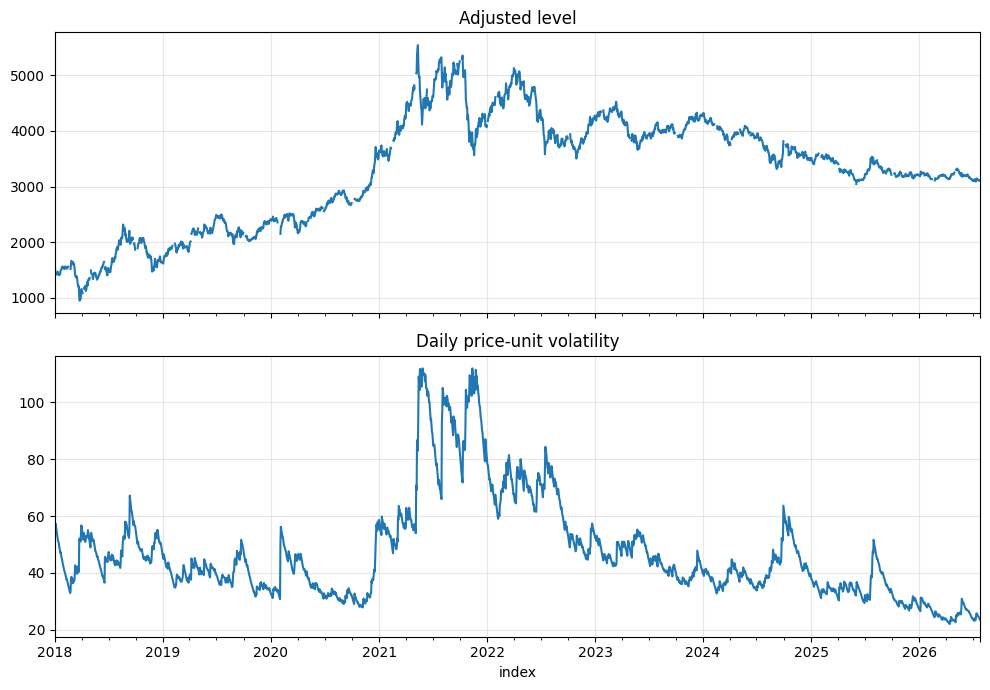

In [26]:
adjusted = fixed_system.rawdata.get_daily_prices(FOCUS)
denominator = fixed_system.rawdata.daily_denominator_price(FOCUS)
price_returns = fixed_system.rawdata.daily_returns(FOCUS)
percentage_returns = fixed_system.rawdata.get_daily_percentage_returns(FOCUS)
price_vol = fixed_system.rawdata.daily_returns_volatility(FOCUS)
percentage_vol = fixed_system.rawdata.get_daily_percentage_volatility(FOCUS)

raw_table = pd.concat({
    "adjusted level": adjusted,
    "held-contract denominator": denominator,
    "price difference": price_returns,
    "percentage return": percentage_returns,
    "price-unit vol": price_vol,
    "percentage vol": percentage_vol,
}, axis=1)
display(raw_table.dropna(how="any").tail())
print("current volatility function:",
      fixed_system.config.volatility_calculation["func"])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
adjusted.loc[PLOT_START:].plot(ax=axes[0], title="Adjusted level")
price_vol.loc[PLOT_START:].plot(ax=axes[1], title="Daily price-unit volatility")
plt.tight_layout()

New raw-data subclasses make sense when reusable preprocessing deserves
diagnostic visibility—for example fundamental factors or moving averages.
For a new asset class, decide explicitly what `daily_denominator_price`
means. The Chinese futures class already makes the correct held-contract
choice.

### Rules and the `TradingRule` container

A `TradingRule` stores a function, ordered data-method references, and keyword
arguments. Functions may be passed directly or by import string; definitions
may be a callable, tuple, dictionary, or an already-built object. Missing
`data` defaults to `data.daily_prices`.

In [27]:
from systems.provided.rules.ewmac import ewmac, ewmac_forecast_with_defaults

rule_forms = {
    "callable / default data": TradingRule(ewmac_forecast_with_defaults),
    "string": TradingRule(
        "systems.provided.rules.ewmac.ewmac_forecast_with_defaults"
    ),
    "separate args": TradingRule(
        ewmac,
        data=["rawdata.get_daily_prices", "rawdata.daily_returns_volatility"],
        other_args={"Lfast": 16, "Lslow": 64},
    ),
    "tuple": TradingRule((
        "systems.provided.rules.ewmac.ewmac",
        ["rawdata.get_daily_prices", "rawdata.daily_returns_volatility"],
        {"Lfast": 16, "Lslow": 64},
    )),
    "dictionary": TradingRule({
        "function": "systems.provided.rules.ewmac.ewmac",
        "data": ["rawdata.get_daily_prices", "rawdata.daily_returns_volatility"],
        "other_args": {"Lfast": 16, "Lslow": 64},
    }),
}
for label, rule in rule_forms.items():
    print(label, "→", rule)

callable / default data → TradingRule; function: <function ewmac_forecast_with_defaults at 0x12d72dc60>, data: data.daily_prices (args: {}) and other_args: 
string → TradingRule; function: <function ewmac_forecast_with_defaults at 0x12d72dc60>, data: data.daily_prices (args: {}) and other_args: 
separate args → TradingRule; function: <function ewmac at 0x12d72e3b0>, data: rawdata.get_daily_prices (args: {}), rawdata.daily_returns_volatility (args: {}) and other_args: Lfast, Lslow
tuple → TradingRule; function: <function ewmac at 0x12d72e3b0>, data: rawdata.get_daily_prices (args: {}), rawdata.daily_returns_volatility (args: {}) and other_args: Lfast, Lslow
dictionary → TradingRule; function: <function ewmac at 0x12d72e3b0>, data: rawdata.get_daily_prices (args: {}), rawdata.daily_returns_volatility (args: {}) and other_args: Lfast, Lslow


### Data arguments for rules

Leading underscores route keywords to data methods: `_span` goes to the first
data method, `__span` to the second, while ordinary names go to the rule
function. Data methods must accept only `instrument_code` plus keyword
arguments. This lets cached raw-data calculations be reused across rules.

In [28]:
from systems.forecasting import Rules
from systems.system_cache import diagnostic

class MovingAverageRawData(RawData):
    @diagnostic()
    def moving_average(self, instrument_code, span=8):
        return self.get_daily_prices(instrument_code).ewm(span=span).mean()

def moving_average_difference(fast, slow, vol, multiplier=1.0):
    return multiplier * (fast - slow) / vol.ffill()

data_argument_rule = TradingRule({
    "function": moving_average_difference,
    "data": [
        "rawdata.moving_average",
        "rawdata.moving_average",
        "rawdata.daily_returns_volatility",
    ],
    "other_args": {"_span": 16, "__span": 64, "multiplier": 1.0},
})
data_argument_system = System(
    [MovingAverageRawData(), Rules({"ma16_64": data_argument_rule})],
    dbFuturesSimData(),
    Config({}),
)
display(data_argument_system.rules.get_raw_forecast(FOCUS, "ma16_64").dropna().tail())

index
2026-07-21   -1.4876
2026-07-22   -1.5427
2026-07-23   -1.5532
2026-07-24   -1.5594
2026-07-27   -1.5662
Freq: B, Name: price, dtype: float64

### Lists of rules, variations, pre-baked systems, and on-the-fly changes

`Rules` accepts one rule, a list (automatic names), or a dictionary (chosen
names). With no argument it lazily parses `config.trading_rules` after joining
a system. Variation helpers copy a base rule while changing one or several
parameters. Passing a rules dictionary into `futures_system` is the clean
interactive route.

In [29]:
from systems.trading_rules import create_variations, create_variations_oneparameter

base_rule = TradingRule(
    "systems.provided.rules.ewmac.ewmac_forecast_with_defaults"
)
one_parameter = create_variations_oneparameter(
    base_rule, [4, 16, 32], "Lfast"
)
two_parameters = create_variations(
    base_rule,
    [
        {"Lfast": 4, "Lslow": 16},
        {"Lfast": 16, "Lslow": 64},
    ],
    key_argname="Lfast",
)

print("one-parameter variations:", sorted(one_parameter))
print("two-parameter variations:", sorted(two_parameters))
print("config-loaded rules:", sorted(fixed_system.rules.trading_rules()))

interactive_rule_system = System(
    [RawData(), Rules(two_parameters)], dbFuturesSimData(), Config({})
)
chosen_name = sorted(two_parameters)[0]
display(interactive_rule_system.rules.get_raw_forecast(FOCUS, chosen_name).dropna().tail(2))

one-parameter variations: ['Lfast_16', 'Lfast_32', 'Lfast_4']
two-parameter variations: ['Lfast_16', 'Lfast_4']
config-loaded rules: ['carry', 'ewmac16_64', 'ewmac32_128']


index
2026-07-24   -2.3195
2026-07-27   -2.3675
Freq: B, Name: price, dtype: float64

Directly editing `system.rules._trading_rules` is advanced and private. If you
do it, first force parsing, insert only real `TradingRule` objects, and update
forecast weights or rule variations too. There is usually no speed benefit
to deleting an unused rule: rules outside the active weight/variation set are
not calculated.

In [30]:
rule_edit_system = futures_system()
processed = rule_edit_system.rules.trading_rules()
before = sorted(processed)
rule_edit_system.rules._trading_rules["temporary_rule"] = TradingRule(
    "systems.provided.rules.ewmac.ewmac_forecast_with_defaults",
    other_args={"Lfast": 8, "Lslow": 32},
)
after_add = sorted(rule_edit_system.rules._trading_rules)
rule_edit_system.rules._trading_rules.pop("temporary_rule")
print("before:", before)
print("after temporary add:", after_add)
print("restored:", sorted(rule_edit_system.rules._trading_rules))

before: ['carry', 'ewmac16_64', 'ewmac32_128']
after temporary add: ['carry', 'ewmac16_64', 'ewmac32_128', 'temporary_rule']
restored: ['carry', 'ewmac16_64', 'ewmac32_128']


### Forecast scale and cap

Fixed scalars can live inside each rule or in `forecast_scalars`; the rule-
local value wins. Defaults are scalar 1 and cap 20. Estimated scalars target
an average absolute forecast of 10 with an expanding out-of-sample estimate.
Pooling across instruments is recommended; individual estimates are useful
mainly to diagnose a poorly portable rule. `backfill=True` fills the earliest
period with the first available scale and is a small, explicit look-ahead.

In [31]:
fixed_scalar = fixed_system.forecastScaleCap.get_forecast_scalar(
    FOCUS, "ewmac16_64"
)
pooled_scalar = estimated_system.forecastScaleCap.get_forecast_scalar(
    FOCUS, "ewmac16_64"
)

individual_scalar_config = Config([
    str(CONFIG_PATH),
    {
        "use_forecast_scale_estimates": True,
        "forecast_scalar_estimate": {"pool_instruments": False},
    },
])
individual_scalar_system = futures_system(
    data=dbFuturesSimData(), config=individual_scalar_config
)
individual_scalar = individual_scalar_system.forecastScaleCap.get_forecast_scalar(
    FOCUS, "ewmac16_64"
)

scalar_comparison = pd.concat({
    "fixed": fixed_scalar,
    "pooled estimate": pooled_scalar,
    "individual estimate": individual_scalar,
}, axis=1)
display(scalar_comparison.dropna(how="all").tail())
print("forecast cap:", fixed_system.forecastScaleCap.get_forecast_cap())

,fixed,pooled estimate,individual estimate
index,,,
2026-07-21,3.7500,5.0496,4.2760
2026-07-22,3.7500,5.0497,4.2764
2026-07-23,3.7500,5.0498,4.2768
2026-07-24,3.7500,5.0499,4.2771
2026-07-27,3.7500,5.0500,4.2775


forecast cap: 20.0


### Combine forecasts: fixed and estimated weights and multipliers

Fixed forecast weights may be common or nested by instrument; absent weights
default to equal weighting. The FDM may likewise be one scalar or a mapping
by instrument. Missing early forecasts cause available fixed weights to be
renormalised, but the fixed FDM is not retrospectively adjusted.

Estimated weights use rule P&L, costs, and the optimisation settings covered
in Part 3. Estimated FDM combines time-varying weights with forecast
correlations; pooled weights/correlations give matching FDMs across markets.

In [32]:
fixed_combine = pd.DataFrame({
    "configured weight": fixed_system.config.forecast_weights,
})
display(fixed_combine)

combine_summary = pd.Series({
    "fixed FDM": fixed_system.combForecast.get_forecast_diversification_multiplier(
        FOCUS
    ).dropna().iloc[-1],
    "estimated FDM": estimated_system.combForecast.get_forecast_diversification_multiplier(
        FOCUS
    ).dropna().iloc[-1],
    "fixed combined forecast": fixed_system.combForecast.get_combined_forecast(
        FOCUS
    ).dropna().iloc[-1],
    "estimated combined forecast": estimated_system.combForecast.get_combined_forecast(
        FOCUS
    ).dropna().iloc[-1],
})
display(combine_summary)

,configured weight
carry,0.5000
ewmac16_64,0.3000
ewmac32_128,0.2000


fixed FDM                       1.3000
estimated FDM                   1.2119
fixed combined forecast        -9.4748
estimated combined forecast   -10.2751
dtype: float64

### Remove expensive rules

`forecast_weight_estimate.ceiling_cost_SR` controls which rules enter pooled
optimisation. The current post-processing name is
`forecast_post_ceiling_cost_SR`; it can remove expensive rules after fitting
and also applies to fixed weights. A deliberately tight 0.015 SR ceiling
shows why the surviving set can differ by Chinese market.

In [33]:
cost_ceiling_config = Config([
    str(CONFIG_PATH),
    {"forecast_post_ceiling_cost_SR": 0.015},
])
cost_ceiling_system = futures_system(
    data=dbFuturesSimData(), config=cost_ceiling_config
)
cost_rows = []
for code_ in INSTRUMENTS:
    for rule_name in ["ewmac16_64", "ewmac32_128", "carry"]:
        cost_rows.append({
            "instrument": code_,
            "rule": rule_name,
            "SR cost": cost_ceiling_system.accounts.get_SR_cost_for_instrument_forecast(
                code_, rule_name
            ),
            "survives 0.015": rule_name in cost_ceiling_system.combForecast.cheap_trading_rules_post_processing(code_),
        })
display(pd.DataFrame(cost_rows).set_index(["instrument", "rule"]))

SR cost  survives 0.015
instrument rule                                
SHFE_RB    ewmac16_64    0.0196           False
           ewmac32_128   0.0143            True
           carry         0.0083            True
DCE_M      ewmac16_64    0.0256           False
           ewmac32_128   0.0186           False
           carry         0.0108            True
CFFEX_IF   ewmac16_64    0.0050            True
           ewmac32_128   0.0043            True
           carry         0.0035            True
CFFEX_T    ewmac16_64    0.0248           False
           ewmac32_128   0.0187           False
           carry         0.0119            True

### Forecast mapping

Mapping introduces a no-trade zone around zero, then steepens the remaining
forecast so average magnitude is preserved. If a mapping is absent for an
instrument, no mapping occurs. Here `threshold=5`, `a=1.2`, and `b=1.6`
satisfy `b = cap × a / (cap - threshold)` for a cap of 20.

,before mapping,after mapping
index,,
2026-07-21,-9.2202,-6.7524
2026-07-22,-9.3215,-6.9145
2026-07-23,-9.3591,-6.9746
2026-07-24,-9.4196,-7.0714
2026-07-27,-9.4748,-7.1596


Text(0, 0.5, 'forecast')

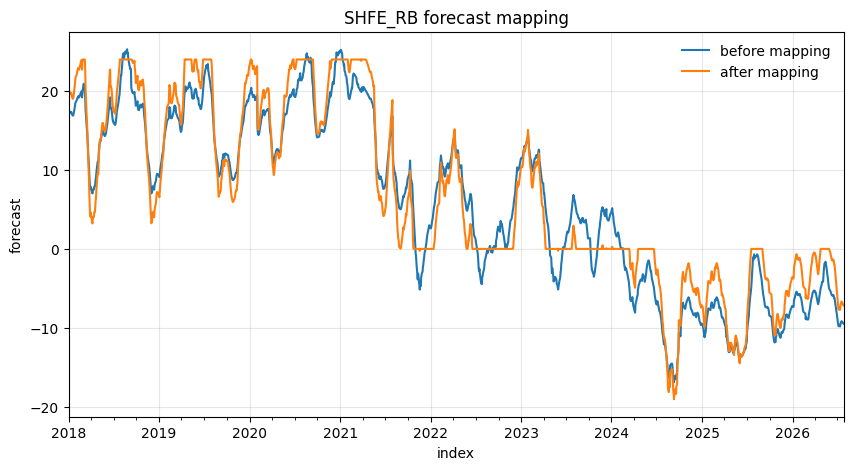

In [34]:
mapping_config = Config([
    str(CONFIG_PATH),
    {
        "forecast_mapping": {
            "SHFE_RB": {"a_param": 1.2, "b_param": 1.6, "threshold": 5.0}
        }
    },
])
mapping_system = futures_system(
    data=dbFuturesSimData(), config=mapping_config
)
before_mapping = mapping_system.combForecast.get_raw_combined_forecast_before_mapping(
    FOCUS
)
after_mapping = mapping_system.combForecast.get_combined_forecast(FOCUS)
mapping_comparison = pd.concat({
    "before mapping": before_mapping,
    "after mapping": after_mapping,
}, axis=1).loc[PLOT_START:]
display(mapping_comparison.tail())
ax = mapping_comparison.plot(title="SHFE_RB forecast mapping")
ax.set_ylabel("forecast")

### Position scaling

Position sizing converts a combined forecast into contracts. Capital and the
annual percentage target define a daily cash-volatility budget. Point value,
held-contract price, percentage volatility, and FX determine the cash risk of
one contract. A forecast of 10 receives the average subsystem position; the
actual forecast scales it linearly.

In [35]:
position_details = systemDiag(fixed_system).calculation_details(FOCUS)
display(position_details)

cash_target = fixed_system.positionSize.get_daily_cash_vol_target()
display(pd.Series(cash_target))
position_components = {
    "block value": fixed_system.positionSize.get_block_value(FOCUS),
    "instrument currency vol": fixed_system.positionSize.get_instrument_currency_vol(FOCUS),
    "account currency vol": fixed_system.positionSize.get_instrument_value_vol(FOCUS),
    "average subsystem position": fixed_system.positionSize.get_average_position_at_subsystem_level(FOCUS),
    "subsystem position": fixed_system.positionSize.get_subsystem_position(FOCUS),
}
display(pd.concat(position_components, axis=1).dropna(how="all").tail())

{'Fcast': -9.474768003883058,
 'Price': 3113.0,
 'S(P_d)': 23.616044341668623,
 'S(%daily)': 0.7586265448656802,
 'Blck val': 311.3,
 'ICV': 236.16044341668623,
 'FX': 1.0,
 'IVV': 236.16044341668623,
 'Vol scalar': 423.44093935984864,
 'SS Pos': -401.20046637808804,
 'Pos.': -150.4501748917832,
 'Instr.Wt': 0.25000000000000033,
 'IDM': 1.5,
 'Blc size': 10.0,
 'Daily VolTgt': 100000.0,
 'Bfr+': -134.57113966578885,
 'Bfr-': -166.32921011777756}

0   100,000.0000
dtype: float64

,block value,instrument currency vol,account currency vol,average subsystem position,subsystem position
index,,,,,
2026-07-21,311.6000,246.3030,246.3030,406.0040,-374.3458
2026-07-22,310.3000,244.3103,244.3103,409.3155,-381.5451
2026-07-23,311.2000,242.4958,242.4958,412.3783,-385.9508
2026-07-24,311.4000,239.3714,239.3714,417.7608,-393.5142
2026-07-27,311.3000,236.1604,236.1604,423.4409,-401.2005


### Portfolio construction: weights and IDM

Instrument weights combine subsystem positions; IDM restores risk lost to
diversification. Fixed weights default to equal and IDM to 1. Estimated
weights use subsystem P&L, while estimated IDM uses instrument correlations.
Different history start dates cause fixed weights to be renormalised among
available markets; a fixed IDM is not adjusted for the smaller early set.

In [36]:
portfolio_summary = pd.Series({
    "fixed SHFE_RB weight": fixed_system.portfolio.get_instrument_weights()[FOCUS].dropna().iloc[-1],
    "fixed IDM": fixed_system.portfolio.get_instrument_diversification_multiplier().dropna().iloc[-1],
    "estimated SHFE_RB weight": estimated_system.portfolio.get_instrument_weights()[FOCUS].dropna().iloc[-1],
    "estimated IDM": estimated_system.portfolio.get_instrument_diversification_multiplier().dropna().iloc[-1],
})
display(portfolio_summary)

positions = pd.concat({
    "subsystem": fixed_system.positionSize.get_subsystem_position(FOCUS),
    "without IDM": fixed_system.portfolio.get_notional_position_without_idm(FOCUS),
    "final notional": fixed_system.portfolio.get_notional_position(FOCUS),
}, axis=1)
display(positions.dropna(how="all").tail())

fixed SHFE_RB weight       0.2500
fixed IDM                  1.5000
estimated SHFE_RB weight   0.2430
estimated IDM              1.8469
dtype: float64

,subsystem,without IDM,final notional
index,,,
2026-07-21,-374.3458,-93.5864,-140.3797
2026-07-22,-381.5451,-95.3863,-143.0794
2026-07-23,-385.9508,-96.4877,-144.7315
2026-07-24,-393.5142,-98.3786,-147.5678
2026-07-27,-401.2005,-100.3001,-150.4502


### Buffering and position inertia

`position` buffers use a fraction of the current target. `forecast` buffers
use a fraction of the average position at forecast 10 and therefore do not
collapse near zero. `none` disables buffering. Outside the band, trading may
go to the nearest edge or all the way to target. Accounts may round to whole
contracts.

In [37]:
buffer_rows = []
buffer_systems = {}
for method, trade_to_edge in [
    ("position", False), ("forecast", True), ("none", True)
]:
    buffer_config = Config([
        str(CONFIG_PATH),
        {
            "buffer_method": method,
            "buffer_size": 0.10,
            "buffer_trade_to_edge": trade_to_edge,
        },
    ])
    candidate = futures_system(
        data=dbFuturesSimData(), config=buffer_config
    )
    buffer_systems[method] = candidate
    held = candidate.accounts.get_buffered_position(FOCUS, roundpositions=True)
    buffer_rows.append({
        "method": method,
        "trade to edge": trade_to_edge,
        "latest rounded position": held.dropna().iloc[-1],
        "annual turnover": candidate.accounts.instrument_turnover(FOCUS),
    })
display(pd.DataFrame(buffer_rows).set_index("method"))
display(fixed_system.portfolio.get_buffers_for_position(FOCUS).dropna().tail())

,trade to edge,latest rounded position,annual turnover
method,,,
position,False,-136.0000,6.7603
forecast,True,-143.0000,5.3374
none,True,-150.0000,9.6909


,top_pos,bot_pos
index,,
2026-07-21,-125.1545,-155.6048
2026-07-22,-127.7301,-158.4288
2026-07-23,-129.2674,-160.1957
2026-07-24,-131.9018,-163.2339
2026-07-27,-134.5711,-166.3292


### Accounting stage and its outputs

The accounting stage exposes portfolio, instrument, subsystem, rule, and
instrument-rule P&L. `delayfill=True` assumes the next business-row close;
portfolio and instrument curves round by default, while subsystem/rule
diagnostics generally do not. Buffering applies only to the final portfolio
position, so lower-level diagnostic costs can be overstated.

In [38]:
account_outputs = {
    "portfolio": fixed_system.accounts.portfolio(),
    "instrument contribution": fixed_system.accounts.pandl_for_instrument(FOCUS),
    "standalone subsystem": fixed_system.accounts.pandl_for_subsystem(FOCUS),
    "one instrument + rule": fixed_system.accounts.pandl_for_instrument_forecast(
        FOCUS, "carry"
    ),
    "weighted instrument + rule": fixed_system.accounts.pandl_for_instrument_forecast_weighted(
        FOCUS, "carry"
    ),
    "rules within instrument": fixed_system.accounts.pandl_for_instrument_rules(FOCUS),
    "rules within instrument, unweighted": fixed_system.accounts.pandl_for_instrument_rules_unweighted(FOCUS),
    "carry across instruments": fixed_system.accounts.pandl_for_trading_rule("carry"),
    "carry weighted to total capital": fixed_system.accounts.pandl_for_trading_rule_weighted("carry"),
    "carry unweighted": fixed_system.accounts.pandl_for_trading_rule_unweighted("carry"),
    "all subsystems": fixed_system.accounts.pandl_across_subsystems(),
    "all rules": fixed_system.accounts.pandl_for_all_trading_rules(),
    "all rules, unweighted": fixed_system.accounts.pandl_for_all_trading_rules_unweighted(),
}

output_types = []
for name, obj in account_outputs.items():
    output_types.append({
        "output": name,
        "class": type(obj).__name__,
        "weighted": getattr(obj, "weighted", None),
        "members": len(obj.asset_columns) if hasattr(obj, "asset_columns") else 1,
    })
display(pd.DataFrame(output_types).set_index("output"))

,class,weighted,members
output,,,
portfolio,accountCurveGroup,True,4
instrument contribution,accountCurve,True,1
standalone subsystem,accountCurve,False,1
one instrument + rule,accountCurve,False,1
weighted instrument + rule,accountCurve,True,1
rules within instrument,accountCurveGroup,True,3
"rules within instrument, unweighted",accountCurveGroup,False,3
carry across instruments,accountCurveGroup,True,4
carry weighted to total capital,accountCurveGroup,True,4


### `accountCurve`

An `accountCurve` wraps gross P&L, costs, and net P&L. Chain curve type,
frequency, and units in any order: `.gross.weekly.percent` and
`.percent.weekly.gross` are equivalent. `.value_terms` reverses percentage
display. Statistics, cumulative curves, drawdowns, and rolling volatility are
methods on the wrapper.

,gross,costs,net
2026-07-21,0.1144,NaN,0.1144
2026-07-22,0.1859,NaN,0.1859
2026-07-23,-0.1287,NaN,-0.1287
2026-07-24,-0.0286,NaN,-0.0286
2026-07-27,0.0143,NaN,0.0143


daily net Sharpe                    0.9910
weekly gross standard deviation     1.1595
annual median costs                -0.0903
annualised daily volatility         8.6890
worst drawdown                    -16.8748
t statistic                         3.8176
p value                             0.0001
dtype: float64

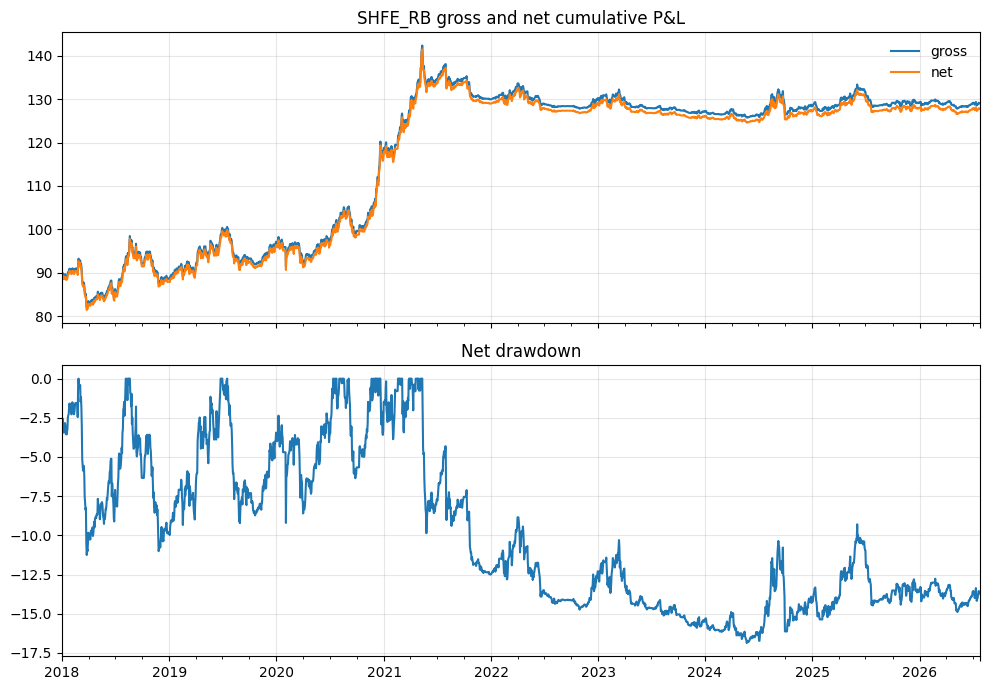

In [39]:
instrument_curve = fixed_system.accounts.pandl_for_instrument(FOCUS)
display(instrument_curve.percent.to_ncg_frame().tail())
curve_stats = pd.Series({
    "daily net Sharpe": instrument_curve.percent.daily.sharpe(),
    "weekly gross standard deviation": instrument_curve.percent.gross.weekly.std(),
    "annual median costs": instrument_curve.percent.costs.annual.median(),
    "annualised daily volatility": instrument_curve.percent.daily.ann_std(),
    "worst drawdown": instrument_curve.percent.worst_drawdown(),
    "t statistic": instrument_curve.percent.t_stat(),
    "p value": instrument_curve.percent.p_value(),
})
display(curve_stats)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
instrument_curve.percent.gross.curve().loc[PLOT_START:].plot(
    ax=axes[0], label="gross"
)
instrument_curve.percent.net.curve().loc[PLOT_START:].plot(
    ax=axes[0], label="net", title="SHFE_RB gross and net cumulative P&L"
)
axes[0].legend()
instrument_curve.percent.drawdown().loc[PLOT_START:].plot(
    ax=axes[1], title="Net drawdown"
)
plt.tight_layout()

### `accountCurveGroup`, nested groups, and weighting

A group behaves like the aggregate curve, while `.asset_columns` and
`group["name"]` expose members. `.to_frame()` displays every member and
`.get_stats()` calculates a statistic across them with equal or history-
length weighting. `pandl_for_all_trading_rules()` is nested: each rule member
is itself an instrument group.

Weighted members are contributions to total system capital; their standalone
statistics can be non-stationary as weights change. Unweighted members are
useful individually, but summing the group usually has no portfolio meaning.
`pandl_for_trading_rule` is deliberately intermediate: normalised to full
strategy risk but internally weighted across instruments.

In [40]:
portfolio_group = fixed_system.accounts.portfolio()
print("members:", portfolio_group.asset_columns)
display(portfolio_group.percent.to_frame().tail())
print("SHFE_RB contribution Sharpe:",
      portfolio_group[FOCUS].percent.sharpe())

sharpes = portfolio_group.get_stats("sharpe", curve_type="net", freq="daily")
display(pd.Series(sharpes, name="net Sharpe"))
print("time-weighted mean:", sharpes.mean(timeweighted=True))
print("equal-weighted mean:", sharpes.mean(timeweighted=False))
print("cross-sectional t-stat / p-value:",
      sharpes.tstat(timeweighted=True), sharpes.pvalue(timeweighted=True))

nested = fixed_system.accounts.pandl_for_all_trading_rules()
carry_group = nested["carry"]
print("nested members (rules):", nested.asset_columns)
print("carry members (instruments):", carry_group.asset_columns)
display(carry_group.percent.to_frame().tail(2))

members: ['CFFEX_IF', 'CFFEX_T', 'DCE_M', 'SHFE_RB']


,CFFEX_IF,CFFEX_T,DCE_M,SHFE_RB
2026-07-21,0.7020,0.1980,-0.0597,0.1144
2026-07-22,-0.0816,0.4785,0.0025,0.1859
2026-07-23,0.1032,-0.3630,-0.0631,-0.1287
2026-07-24,-0.4872,0.2475,-0.0374,-0.0286
2026-07-27,0.4056,-0.2310,0.0049,0.0143


SHFE_RB contribution Sharpe: 0.991005440001099


CFFEX_IF   0.5362
CFFEX_T    0.5947
DCE_M      0.2479
SHFE_RB    0.9910
Name: net Sharpe, dtype: float64

time-weighted mean: 0.5923216819601088
equal-weighted mean: 0.1481169986145141


cross-sectional t-stat / p-value: 3.539345100258388 0.03838167532400719
nested members (rules): ['ewmac16_64', 'ewmac32_128', 'carry']
carry members (instruments): ['CFFEX_IF', 'CFFEX_T', 'DCE_M', 'SHFE_RB']


,CFFEX_IF,CFFEX_T,DCE_M,SHFE_RB
index,,,,
2026-07-24,-1.3819,0.4544,-1.2880,-0.0740
2026-07-27,1.1710,-0.4197,1.9204,0.0359


### Test account curves

`curve.t_test()` tests a zero mean. To compare two aligned curves use the
current `account_t_test` location below. Both are conventional t-tests whose
independence/normality assumptions are dubious for financial returns; treat
them as diagnostics, not proof.

In [41]:
from systems.accounts.curves.account_curve_analysis import account_t_test

rebar_test = fixed_system.accounts.pandl_for_subsystem("SHFE_RB").percent.t_test()
paired_test = account_t_test(
    fixed_system.accounts.pandl_for_subsystem("SHFE_RB").percent,
    fixed_system.accounts.pandl_for_subsystem("DCE_M").percent,
)
print("SHFE_RB zero-mean test:", rebar_test)
print("SHFE_RB versus DCE_M paired test:", paired_test)

SHFE_RB zero-mean test: TtestResult(statistic=3.563084379107244, pvalue=0.0003710272488672287, df=3798)
SHFE_RB versus DCE_M paired test: AccountTTestResult(diff=0.04371004720589857, statistic=1.9328038156017813, pvalue=0.053334646027186385)


### Costs and turnover

Forecast-level diagnostics always use standardised Sharpe-ratio costs.
Position-level P&L can use actual trade costs (`use_SR_costs: false`) or the
faster SR drag approximation. Actual costs normally scale historic currency
costs by volatility; `vol_normalise_currency_costs: false` is useful for a
live-like comparison, but not preferred for long historical work.

The manual's no-argument `turnover_at_portfolio_level()` snippet is stale.
That method now takes one instrument; use `total_portfolio_level_turnover()`
to add the portfolio-level contributions across all instruments.

Configured Chinese costs are half-spreads in price points; per-block,
percentage, and per-trade commissions are also supported. Holding costs count
rolls. Per-trade charges require rounded positions.

In [42]:
sr_cost_config = Config([str(CONFIG_PATH), {"use_SR_costs": True}])
sr_cost_system = futures_system(
    data=dbFuturesSimData(), config=sr_cost_config
)

turnover_and_costs = pd.Series({
    "portfolio turnover": fixed_system.accounts.total_portfolio_level_turnover(),
    "SHFE_RB subsystem turnover": fixed_system.accounts.subsystem_turnover(FOCUS),
    "SHFE_RB instrument turnover": fixed_system.accounts.instrument_turnover(FOCUS),
    "SHFE_RB carry forecast turnover": fixed_system.accounts.forecast_turnover(FOCUS, "carry"),
    "rolls per year": fixed_system.accounts.get_rolls_per_year(FOCUS),
    "SR cost per trade": fixed_system.accounts.get_SR_cost_per_trade_for_instrument(FOCUS),
    "SR holding cost": fixed_system.accounts.get_SR_holding_cost_only(FOCUS),
    "SR trading cost at turnover 5": fixed_system.accounts.get_SR_trading_cost_only_given_turnover(FOCUS, 5.0),
    "SR total cost at turnover 5": fixed_system.accounts.get_SR_cost_given_turnover(FOCUS, 5.0),
    "SR cost for carry": fixed_system.accounts.get_SR_cost_for_instrument_forecast(FOCUS, "carry"),
})
display(turnover_and_costs)

cost_method_comparison = pd.Series({
    "actual-cost annual drag (%)": fixed_system.accounts.portfolio().percent.costs.ann_mean(),
    "SR-cost annual drag (%)": sr_cost_system.accounts.portfolio().percent.costs.ann_mean(),
})
display(cost_method_comparison)

portfolio turnover                8.0603
SHFE_RB subsystem turnover        9.8698
SHFE_RB instrument turnover       5.3374
SHFE_RB carry forecast turnover   1.8072
rolls per year                    3.0000
SR cost per trade                 0.0011
SR holding cost                   0.0064
SR trading cost at turnover 5     0.0053
SR total cost at turnover 5       0.0117
SR cost for carry                 0.0083
dtype: float64

actual-cost annual drag (%)   -0.2118
SR-cost annual drag (%)       -0.2692
dtype: float64

# Part 3 — Processes

## File names

Repository-relative dotted names, ordinary slash paths, absolute path strings,
and a separate directory/filename are supported. Dots inside a real directory
or filename are ambiguous in dotted notation, so use an absolute string or a
separate filename. The current combined filename resolver does not reliably
accept `pathlib.Path`, even though some adjacent APIs do. Windows absolute
syntax is documented but not executed on this macOS notebook host.

In [43]:
from syscore.fileutils import get_resolved_pathname, resolve_path_and_filename_for_package

path_examples = {
    "absolute path string": resolve_path_and_filename_for_package(str(CONFIG_PATH)),
    "repository dotted": resolve_path_and_filename_for_package(
        "examples.chinese_futures.backtesting_tutorial.config.yaml"
    ),
    "path plus filename": resolve_path_and_filename_for_package(
        "examples.chinese_futures.backtesting_tutorial", "config.yaml"
    ),
    "resolved directory": get_resolved_pathname(TUTORIAL_DIR),
}
portable_path_examples = {
    key: str(value).replace(str(TUTORIAL_DIR.parents[2]), "<repo>")
    for key, value in path_examples.items()
}
display(pd.Series(portable_path_examples))

absolute path string    <repo>/examples/chinese_futures/backtesting_tu...
repository dotted       <repo>/examples/chinese_futures/backtesting_tu...
path plus filename      <repo>/examples/chinese_futures/backtesting_tu...
resolved directory      <repo>/examples/chinese_futures/backtesting_tu...
dtype: object

## Logging

Systems, stages, configs, and data objects have `.log`. Simulation logging is
configured through Python logging; `PYSYS_LOGGING_CONFIG` may point to another
YAML configuration. Use parameterised messages and structured attributes
instead of `print` in reusable or headless production code.

In [44]:
from syslogging.logger import get_logger

log = get_logger("backtesting_tutorial", {"stage": "demonstration"})
log.warning(
    "Structured Chinese-futures example for %s",
    FOCUS,
    instrument_code=FOCUS,
)
print("system logger:", type(fixed_system.log).__name__)
print("stage logger:", type(fixed_system.rawdata.log).__name__)

system logger: DynamicAttributeLogger
stage logger: DynamicAttributeLogger


## Optimisation

Forecast and instrument weight estimation share the same process: prepare
gross and net returns, choose a fit schedule, estimate moments, optimise, then
clean/smooth/post-process weights. Weekly data is normally enough and much
faster than daily.

Forecast weights may pool gross returns across instruments. Rules first face
`ceiling_cost_SR`; `forecast_post_ceiling_cost_SR` may remove expensive rules
after fitting. `forecast_cost_estimates` controls whether turnover or total
cost is pooled. For either forecast or instrument weights,
`equalise_gross`, `cost_multiplier`, and `apply_cost_weight` decide how costs
enter before or after optimisation.

### Fitting periods and moment estimates

- `expanding` is the normal out-of-sample choice;
- `rolling` uses only `rollyears` of history;
- `in_sample` leaks future information and is only a speed/debugging tool.

Correlations, means, and standard deviations each have configurable
estimators, exponential weighting, lookbacks, and minimum observations.
Exponential moments are especially useful for shrinkage or one-period fits.

In [45]:
optimisation_config = estimated_system.config
optimisation_settings = {
    "forecast weighting": optimisation_config.forecast_weight_estimate,
    "instrument weighting": optimisation_config.instrument_weight_estimate,
    "forecast costs": optimisation_config.forecast_cost_estimates,
}
for label, settings in optimisation_settings.items():
    print(f"\n{label}")
    display(pd.Series(settings, dtype=object))


forecast weighting


method                                                          handcraft
date_method                                                     expanding
cost_multiplier                                                    2.0000
ann_target_SR                                                      0.5000
equalise_gross                                                      False
func                    sysquant.optimisation.generic_optimiser.generi...
shrinkage_corr                                                     0.5000
ceiling_cost_SR                                                      9999
rollyears                                                              20
vol_estimate            {'func': 'sysquant.estimators.stdev_estimator....
apply_cost_weight                                                   False
frequency                                                               W
equalise_SR                                                         False
pool_gross_returns                    


instrument weighting


method                                                          handcraft
date_method                                                     expanding
cost_multiplier                                                    1.0000
frequency                                                               W
apply_cost_weight                                                   False
ann_target_SR                                                      0.5000
monte_runs                                                            100
mean_estimate           {'func': 'sysquant.estimators.mean_estimator.m...
equalise_gross                                                      False
shrinkage_mean                                                     1.0000
equalise_SR                                                          True
func                    sysquant.optimisation.generic_optimiser.generi...
rollyears                                                              20
cleaning                              


forecast costs


use_pooled_costs       False
use_pooled_turnover     True
dtype: object

### Optimisation methods

The current register contains four methods:

- `equal_weights`: one-over-N among available assets;
- `one_period`: classical Markowitz, stabilised by optional equal Sharpe and
  volatility assumptions;
- `shrinkage`: shrink Sharpe ratios and correlations toward common priors;
- `handcraft`: robust correlation clustering and the recommended default.

The manual retains a bootstrapping heading, but bootstrapping was removed
after a refactor and is not a registered method. We say that plainly instead
of showing code that cannot run.

In [46]:
def small_estimated_system(method, date_method="expanding", rollyears=20):
    config = Config([
        str(CONFIG_PATH),
        {
            "instruments": INSTRUMENTS,
            "rule_variations": ["ewmac16_64", "ewmac32_128", "carry"],
            "use_forecast_scale_estimates": True,
            "use_forecast_weight_estimates": True,
            "use_forecast_div_mult_estimates": True,
            "use_instrument_weight_estimates": True,
            "use_instrument_div_mult_estimates": True,
            "forecast_weight_estimate": {
                "method": method, "date_method": date_method, "rollyears": rollyears,
            },
            "instrument_weight_estimate": {
                "method": method, "date_method": date_method, "rollyears": rollyears,
            },
        },
    ])
    del config.instrument_weights
    return futures_system(data=dbFuturesSimData(), config=config)

method_rows = []
method_systems = {"handcraft": estimated_system}
for method in ["equal_weights", "one_period", "shrinkage", "handcraft"]:
    candidate = method_systems.get(method)
    if candidate is None:
        candidate = small_estimated_system(method)
        method_systems[method] = candidate
    with redirect_stdout(StringIO()):
        forecast_weights = candidate.combForecast.get_forecast_weights(FOCUS)
        instrument_weights = candidate.portfolio.get_instrument_weights()
    method_rows.append({
        "method": method,
        "carry forecast weight": forecast_weights["carry"].dropna().iloc[-1],
        "SHFE_RB instrument weight": instrument_weights[FOCUS].dropna().iloc[-1],
        "CFFEX_T instrument weight": instrument_weights["CFFEX_T"].dropna().iloc[-1],
    })
display(pd.DataFrame(method_rows).set_index("method"))

,carry forecast weight,SHFE_RB instrument weight,CFFEX_T instrument weight
method,,,
equal_weights,0.3333,0.2500,0.2500
one_period,0.7141,0.2277,0.2705
shrinkage,0.4691,0.2384,0.2616
handcraft,0.6921,0.2430,0.2570


### Expanding, rolling, and in-sample fits

The same optimiser can use different fitting schedules. This compact
comparison is descriptive; the in-sample result must never be reported as an
honest historical backtest.

In [47]:
fit_rows = []
for date_method in ["expanding", "rolling", "in_sample"]:
    candidate = (
        estimated_system
        if date_method == "expanding"
        else small_estimated_system("handcraft", date_method=date_method, rollyears=5)
    )
    with redirect_stdout(StringIO()):
        weights = candidate.portfolio.get_instrument_weights()
    latest = weights.dropna(how="all").iloc[-1]
    fit_rows.append({
        "fit schedule": date_method,
        **{code_: latest[code_] for code_ in INSTRUMENTS},
        "honest backtest?": date_method != "in_sample",
    })
display(pd.DataFrame(fit_rows).set_index("fit schedule"))

,SHFE_RB,DCE_M,CFFEX_IF,CFFEX_T,honest backtest?
fit schedule,,,,,
expanding,0.2430,0.2570,0.2430,0.2570,True
rolling,0.2430,0.2570,0.2430,0.2570,True
in_sample,0.1799,0.2631,0.1799,0.3770,False


### Post-processing

`cleaning=True` supplies sensible weights when a fit lacks enough data.
`apply_cost_weight=True` can penalise costs after an optimiser that used gross
returns; do not double-count by also applying a non-zero cost multiplier
without intending to. Weight EWMA spans smooth jumps that would otherwise
cause trading. The post-fit cost ceiling is applied at this stage.

## Estimate correlations and diversification multipliers

Forecast correlations can pool instruments; instrument correlations cannot.
Both are commonly estimated weekly with expanding exponentially weighted
windows, cleaned for missing early history, and floored at zero before a
diversification multiplier is calculated. FDM is instrument-specific, though
pooled inputs often make it identical. Smoothing prevents changes in the
multiplier itself from creating excessive trading, and `dm_max` caps the
result.

In [48]:
forecast_corrs = estimated_system.combForecast.get_forecast_correlation_matrices(FOCUS)
instrument_corrs = estimated_system.portfolio.get_instrument_correlation_matrix()

forecast_corr = forecast_corrs.most_recent_correlation_before_date()
instrument_corr = instrument_corrs.most_recent_correlation_before_date()
display(pd.DataFrame(
    forecast_corr.values,
    index=forecast_corrs.column_names,
    columns=forecast_corrs.column_names,
).rename_axis("latest forecast correlation"))
display(pd.DataFrame(
    instrument_corr.values,
    index=instrument_corrs.column_names,
    columns=instrument_corrs.column_names,
).rename_axis("latest instrument correlation"))

dm_summary = pd.Series({
    "latest SHFE_RB FDM": estimated_system.combForecast.get_forecast_diversification_multiplier(FOCUS).dropna().iloc[-1],
    "latest portfolio IDM": estimated_system.portfolio.get_instrument_diversification_multiplier().dropna().iloc[-1],
    "FDM cap": estimated_system.config.forecast_div_mult_estimate["dm_max"],
    "IDM cap": estimated_system.config.instrument_div_mult_estimate["dm_max"],
})
display(dm_summary)

,carry,ewmac16_64,ewmac32_128
latest forecast correlation,,,
carry,1.0000,0.2789,0.3525
ewmac16_64,0.2789,1.0000,0.8680
ewmac32_128,0.3525,0.8680,1.0000


,CFFEX_IF,CFFEX_T,DCE_M,SHFE_RB
latest instrument correlation,,,,
CFFEX_IF,1.0000,0.0000,0.1666,0.0000
CFFEX_T,0.0000,1.0000,0.0000,0.1772
DCE_M,0.1666,0.0000,1.0000,0.0000
SHFE_RB,0.0000,0.1772,0.0000,1.0000


latest SHFE_RB FDM     1.2119
latest portfolio IDM   1.8469
FDM cap                2.5000
IDM cap                2.5000
dtype: float64

## Specify weights as a hierarchy

Hierarchies preserve high-level style or asset-class allocations when a rule
or market disappears. Leaves are actual rule/instrument names. Group weights
renormalise within branches; optional approximate diversification multipliers
can compensate for deeper groups. Forecast hierarchies may apply the post-
cost ceiling before resolving weights.

In [49]:
hierarchy_config = Config([
    str(CONFIG_PATH),
    {
        "forecast_weights": {
            "auto_weight_from_grouping": {
                "parameters": {
                    "use_approx_DM": False,
                    "apply_forecast_post_ceiling_cost_SR_before_weighting": True,
                },
                "groups": {
                    "trend": {
                        "weight": 0.5,
                        "ewmac16_64": 0.6,
                        "ewmac32_128": 0.4,
                    },
                    "carry_style": {"weight": 0.5, "carry": 1.0},
                },
            }
        },
        "instrument_weights": {
            "auto_weight_from_grouping": {
                "parameters": {"use_approx_DM": False},
                "groups": {
                    "growth_sensitive": {
                        "weight": 0.5,
                        "SHFE_RB": 0.5,
                        "CFFEX_IF": 0.5,
                    },
                    "defensive_and_agricultural": {
                        "weight": 0.5,
                        "CFFEX_T": 0.5,
                        "DCE_M": 0.5,
                    },
                },
            }
        },
    },
])
hierarchy_system = futures_system(
    data=dbFuturesSimData(), config=hierarchy_config
)
display(hierarchy_system.combForecast.get_forecast_weights(FOCUS).dropna().tail(1))
display(hierarchy_system.portfolio.get_instrument_weights().dropna(how="all").tail(1))

,ewmac16_64,carry,ewmac32_128
index,,,
2026-07-27,0.3000,0.5000,0.2000


,CFFEX_IF,CFFEX_T,DCE_M,SHFE_RB
index,,,,
2026-07-27,0.2500,0.2500,0.2500,0.2500


## Capital correction: fixed and varying capital

Most methods use fixed notional capital, keeping risk stable and account
curves comparable. `full_compounding` reinvests gains and losses.
`half_compounding` is the manual's loss-only method: capital can fall below
its initial level but is capped at one after gains. Variable-capital methods
have explicit counterparts for positions, buffers, instrument P&L, and the
whole portfolio.

In [50]:
capital_rows = []
capital_systems = {}
for label, function in [
    ("fixed", "syscore.capital.fixed_capital"),
    ("full compounding", "syscore.capital.full_compounding"),
    ("loss-only / half", "syscore.capital.half_compounding"),
]:
    capital_config = Config([
        str(CONFIG_PATH), {"capital_multiplier": {"func": function}}
    ])
    candidate = futures_system(
        data=dbFuturesSimData(), config=capital_config
    )
    capital_systems[label] = candidate
    multiplier = candidate.accounts.capital_multiplier().dropna()
    variable_curve = candidate.accounts.portfolio_with_multiplier().percent
    capital_rows.append({
        "policy": label,
        "final multiplier": multiplier.iloc[-1],
        "minimum multiplier": multiplier.min(),
        "final cumulative P&L (%)": variable_curve.curve().dropna().iloc[-1],
    })
display(pd.DataFrame(capital_rows).set_index("policy"))

fixed_capital_system = capital_systems["fixed"]
variable_method_pairs = pd.DataFrame({
    "fixed capital": [
        "positionSize.get_daily_cash_vol_target",
        "portfolio.get_notional_position",
        "portfolio.get_buffers_for_position",
        "accounts.get_buffered_position",
        "accounts.pandl_for_instrument",
        "accounts.portfolio",
    ],
    "variable capital": [
        "accounts.get_actual_capital",
        "portfolio.get_actual_position",
        "portfolio.get_actual_buffers_for_position",
        "accounts.get_buffered_position_with_multiplier",
        "accounts.pandl_for_instrument_with_multiplier",
        "accounts.portfolio_with_multiplier",
    ],
})
display(variable_method_pairs)

,final multiplier,minimum multiplier,final cumulative P&L (%)
policy,,,
fixed,1.0000,1.0000,251.8345
full compounding,10.6070,0.9452,250.6868
loss-only / half,0.9738,0.8025,257.3911


,fixed capital,variable capital
0,positionSize.get_daily_cash_vol_target,accounts.get_actual_capital
1,portfolio.get_notional_position,portfolio.get_actual_position
2,portfolio.get_buffers_for_position,portfolio.get_actual_buffers_for_position
3,accounts.get_buffered_position,accounts.get_buffered_position_with_multiplier
4,accounts.pandl_for_instrument,accounts.pandl_for_instrument_with_multiplier
5,accounts.portfolio,accounts.portfolio_with_multiplier


# Part 4 — Reference

## Current system, data, and stage method inventory

The manual's tables distinguish diagnostic, input, and output methods. The
most reliable live reference is still `.methods()` on the current object.
The cells above exercised the principal outputs and diagnostics; this table
shows the complete public surface in this checkout, including methods added
since the prose table was written.

In [51]:
method_objects = {
    "data": fixed_system.data,
    "rawdata": fixed_system.rawdata,
    "rules": fixed_system.rules,
    "forecastScaleCap": fixed_system.forecastScaleCap,
    "combForecast": fixed_system.combForecast,
    "positionSize": fixed_system.positionSize,
    "portfolio": fixed_system.portfolio,
    "accounts": fixed_system.accounts,
}
method_inventory = pd.DataFrame([
    {
        "object": name,
        "public member count": len(obj.methods()),
        "members": ", ".join(obj.methods()),
    }
    for name, obj in method_objects.items()
]).set_index("object")
display(method_inventory)

,public member count,members
object,,
data,35,"all_asset_classes, all_instruments_in_asset_cl..."
rawdata,34,"all_instruments_in_asset_class, annualised_ret..."
rules,5,"get_raw_forecast, methods, passed_trading_rule..."
forecastScaleCap,12,"comb_forecast_stage, config, get_capped_foreca..."
combForecast,42,"accounts_stage, calculation_of_raw_estimated_m..."
positionSize,23,"annual_cash_vol_target, avg_abs_forecast, comb..."
portfolio,72,"accounts_stage, allocate_zero_instrument_weigh..."
accounts,76,"average_forecast, capital_multiplier, config, ..."


## Configuration option inventory

The reference config spans raw-data volatility; rule definitions; fixed or
estimated scalar/cap; fixed or estimated forecast weights and FDM; mapping;
capital/risk; fixed or estimated instrument weights and IDM; buffering;
costs; and capital correction. Values below come from the fully populated
tutorial system, but only a safe allow-list is displayed—private values and
credentials are never inspected.

In [52]:
config_groups = {
    "raw data": ["volatility_calculation"],
    "rules": ["trading_rules"],
    "forecast scale/cap": [
        "use_forecast_scale_estimates", "forecast_scalar",
        "forecast_scalar_estimate", "forecast_cap", "average_absolute_forecast",
    ],
    "forecast combination": [
        "forecast_weights", "rule_variations", "use_forecast_weight_estimates",
        "forecast_weight_estimate", "forecast_weight_ewma_span",
        "forecast_post_ceiling_cost_SR", "forecast_div_multiplier",
        "use_forecast_div_mult_estimates", "forecast_correlation_estimate",
        "forecast_div_mult_estimate", "forecast_mapping",
    ],
    "position sizing": [
        "percentage_vol_target", "notional_trading_capital", "base_currency",
    ],
    "portfolio": [
        "instrument_weights", "instruments", "use_instrument_weight_estimates",
        "instrument_weight_estimate", "instrument_weight_ewma_span",
        "instrument_div_multiplier", "use_instrument_div_mult_estimates",
        "instrument_correlation_estimate", "instrument_div_mult_estimate",
    ],
    "buffering/accounting": [
        "buffer_method", "buffer_size", "buffer_trade_to_edge",
        "use_SR_costs", "vol_normalise_currency_costs",
        "forecast_cost_estimates", "capital_multiplier",
    ],
}

def compact_value(value):
    text = repr(value)
    return text if len(text) <= 120 else text[:117] + "..."

config_rows = []
for group, names in config_groups.items():
    for name in names:
        config_rows.append({
            "section": group,
            "option": name,
            "present": hasattr(fixed_system.config, name),
            "tutorial/current value": compact_value(
                getattr(fixed_system.config, name, "not set")
            ),
        })
display(pd.DataFrame(config_rows).set_index(["section", "option"]))

present                             tutorial/current value
section              option                                                                                       
raw data             volatility_calculation                True  {'func': 'sysquant.estimators.vol.mixed_vol_ca...
rules                trading_rules                         True  {'ewmac16_64': {'function': 'systems.provided....
forecast scale/cap   use_forecast_scale_estimates          True                                              False
                     forecast_scalar                       True                                                1.0
                     forecast_scalar_estimate              True  {'pool_instruments': True, 'func': 'sysquant.e...
                     forecast_cap                          True                                               20.0
                     average_absolute_forecast             True                                               10.0
forecast combination forecast_weights                      True  {'ewmac16_64': 0.3, 'ewmac32_128': 0.2, 'carry...
                     rule_variations                      False                                          'not set'
                     use_forecast_weight_estimates         True                                              False
                     forecast_weight_estimate              True  {'func': 'sysquant.optimisation.generic_optimi...
                     forecast_weight_ewma_span             True                                                125
                     forecast_post_ceiling_cost_SR         True                                                999
                     forecast_div_multiplier               True                                                1.3
                     use_forecast_div_mult_estimates       True                                              False
                     forecast_correlation_estimate         True  {'pool_instruments': True, 'func': 'sysquant.e...
                     forecast_div_mult_estimate            True  {'func': 'sysquant.estimators.diversification_...
                     forecast_mapping                     False                                          'not set'
position sizing      percentage_vol_target                 True                                               16.0
                     notional_trading_capital              True                                           10000000
                     base_currency                         True                                              'CNH'
portfolio            instrument_weights                    True  {'SHFE_RB': 0.25, 'DCE_M': 0.25, 'CFFEX_IF': 0...
                     instruments                          False                                          'not set'
                     use_instrument_weight_estimates       True                                              False
                     instrument_weight_estimate            True  {'func': 'sysquant.optimisation.generic_optimi...
                     instrument_weight_ewma_span           True                                                125
                     instrument_div_multiplier             True                                                1.5
                     use_instrument_div_mult_estimates     True                                              False
                     instrument_correlation_estimate       True  {'func': 'sysquant.estimators.correlation_over...
                     instrument_div_mult_estimate          True  {'func': 'sysquant.estimators.diversification_...
buffering/accounting buffer_method                         True                                         'forecast'
                     buffer_size                           True                                                0.1
                     buffer_trade_to_edge                  True                                               True
                     use_SR_cos

## Important manual-to-current-code corrections

| Manual-era spelling or example | Current working form |
|---|---|
| `system.rawdata.methods.methods()` | `system.rawdata.methods()` |
| robust EWMA volatility shown as the default | current default is `mixed_vol_calc`; robust remains configurable |
| `forecast_cost_estimate` | `forecast_cost_estimates` |
| `post_ceiling_cost_SR` | `forecast_post_ceiling_cost_SR` |
| diversification cap `div_mult` | `dm_max` |
| cache deletion called on `system` | call `system.cache.delete_*` |
| `from syscore.accounting import account_t_test` | `systems.accounts.curves.account_curve_analysis` |
| bootstrapping listed as a method | not implemented or registered now |
| DB example builds `data` but then omits it | pass `data=dbFuturesSimData()` or use this tutorial factory |

Other principles remain intact: adjusted futures levels support differences,
not returns; rebuild a system after config changes unless you deliberately
manage caches; pool stable estimates where sensible; use expanding or rolling
fits; and judge net, costed, buffered portfolios rather than attractive raw
signals.

## Coverage checklist

This final table is intentionally explicit. Each meaningful heading in
`docs/backtesting.md` is represented above; repeated reference entries are
grouped only when they describe the same demonstrated interface.

In [53]:
COVERAGE_TOPICS = {
    "How do I?": [
        "single rule and instrument", "standard futures backtest",
        "estimated futures backtest", "intermediate results", "profitability",
        "config file changes", "config object and new system",
        "in-system config mutation", "private config", "project defaults",
        "fixed and estimated instrument selection", "recent start date",
        "all available instruments", "exclude instruments",
        "zero positive weights", "write a rule", "configure a rule",
        "different data or instruments", "save config and cache",
    ],
    "Data": [
        "generic data API", "csvFuturesSimData architecture",
        "dbFuturesSimData setup and use", "Arctic legacy backend",
        "custom data objects", "simData method contract",
    ],
    "Configuration": [
        "dictionary", "YAML file", "pre-baked system", "config list",
        "CSV-to-YAML utilities", "project defaults", "private precedence",
        "defaults for changed functions", "view parameters", "modify parameters",
        "use config in a system", "custom config options", "save config",
        "export estimated parameters", "why not modify Config",
    ],
    "System": [
        "pre-baked fixed system", "pre-baked estimated system",
        "children/data/config", "system methods", "cache labels and hits",
        "cache on/off", "pickle", "compressed pickle", "selective deletion",
        "protected cache workflow", "live cache pattern", "cache decorators",
        "new pre-baked system", "why not subclass System",
    ],
    "Stages": [
        "stage wiring", "write a stage", "standard stage list",
        "raw-data methods", "price and percentage volatility",
        "new raw-data subclass", "TradingRule forms", "data arguments",
        "Rules from config", "interactive rules", "rule variations",
        "new Rules instance", "rules passed to pre-baked system",
        "on-the-fly private rule edits", "fixed scalar and cap",
        "pooled scalar estimate", "individual scalar estimate",
        "fixed forecast weights/FDM", "estimated forecast weights/FDM",
        "remove expensive rules", "forecast mapping", "position sizing",
        "fixed instrument weights/IDM", "estimated instrument weights/IDM",
        "position and forecast buffers", "capital correction link",
        "account outputs", "accountCurve", "accountCurveGroup", "nested groups",
        "weighted versus unweighted", "account-curve tests", "costs and turnover",
    ],
    "Processes": [
        "file-name formats", "basic logging", "structured logging",
        "optimisation function/data", "expensive assets", "pooled gross returns",
        "net costs", "expanding/in-sample/rolling periods", "moment estimates",
        "equal weights", "one period", "bootstrapping unavailable", "shrinkage",
        "handcrafting", "post-processing", "correlations", "FDM and IDM",
        "hierarchical forecast weights", "hierarchical instrument weights",
        "fixed/full/loss-only capital",
    ],
    "Reference": [
        "system method table", "data method table", "raw-data method table",
        "rules method table", "scale/cap method table", "combine method table",
        "position method table", "portfolio method table", "accounts inputs",
        "accounts diagnostics", "accounts outputs", "volatility config",
        "trading-rules config", "fixed/estimated scalar config", "forecast cap",
        "fixed/estimated forecast weights", "rule variations", "fixed/estimated FDM",
        "mapping config", "capital scaling", "fixed/estimated instrument weights",
        "fixed/estimated IDM", "buffer config", "cost config", "capital config",
    ],
}
coverage_rows = [
    {"manual area": area, "topic": topic, "covered": True}
    for area, topics in COVERAGE_TOPICS.items()
    for topic in topics
]
coverage_checklist = pd.DataFrame(coverage_rows)
assert coverage_checklist["covered"].all()
display(coverage_checklist.groupby("manual area").agg(
    topics=("topic", "count"), covered=("covered", "all")
))
print(f"Coverage checklist: {len(coverage_checklist)} topics, all represented.")

,topics,covered
manual area,,
Configuration,15,True
Data,6,True
How do I?,19,True
Processes,20,True
Reference,25,True
Stages,33,True
System,14,True


Coverage checklist: 132 topics, all represented.


## Where to go next

- `docs/backtesting.md` remains the full prose reference and historical record.
- `docs/tushare_chinese_futures.md` explains how these Chinese stores are built.
- `docs/tushare_data_inspection.md` provides read-only checks for each data stage.
- The other notebooks in `examples/chinese_futures/` move from mechanics into
  point-in-time liquidity, full-universe research, pooling, and strategy
  comparisons.

The useful habit is simple: keep data, config, stage outputs, and accounting
visible. When a backtest surprises you, walk upstream one stage at a time.